# Code used to create figures in "An in situ, interpolated hydrographic climatology of the surface Northwest Atlantic Ocean for 2000-2024"
### Haley Synan<sup>1,2*</sup>., Kimberly Hyde<sup>1</sup>, Colleen Mouw<sup>2</sup>, Chris Melrose<sup>1</sup>, Linus Stoltz<sup>3</sup>, Sarah Salois<sup>1</sup>
<sup>1</sup>NOAA Northeast Fisheries Science Center, Narragansett, RI, USA <br>
<sup>2</sup>Graduate School of Oceanography, University of Rhode Island, Narragansett, USA<br>
<sup>3</sup>Commercial Fisheries Research Foundation<br>
<sup>*</sup>Code author 

### Objectives: 
* Create figures and statistical analysis used in "Surface and bottom in situ, interpolated hydrographic climatologies of the Northwest Atlantic Ocean for 2000-2024". 

### Dependencies:
* Access to the raw data is available [HERE]()

## Load functions 

In [1]:
import pandas as pd
import calendar
import os
import cartopy
import matplotlib.pyplot as plt
import numpy as np
from global_land_mask import globe
import geopandas as gpd
import cmocean as cm
import xarray_regrid
import xarray as xr
import copernicusmarine
import cartopy.feature as cfeature
from scipy.ndimage import binary_dilation
from global_land_mask import globe
import rioxarray
from scipy.stats import binned_statistic_2d
from shapely.geometry import mapping
import geopandas as gpd

def calculate_mape(y_true, y_pred):
    # Convert to numpy arrays to ensure consistency
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Create a mask for rows that are NOT NaN in both arrays
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    
    # Apply mask
    y_true_clean = y_true[mask]
    y_pred_clean = y_pred[mask]
    return(mean_absolute_percentage_error(y_true_clean,y_pred_clean)*100)

import calendar
def make_nc(data,df,depth=''):
    lats=data.latitude.unique()
    lons=data.longitude.unique()
    cols_to_fix = data.columns.difference(['latitude', 'longitude'])
    is_land = globe.is_land(data.latitude.values, data.longitude.values)
    data.loc[is_land, cols_to_fix] = np.nan
    #stack dataframe into dataarrays for temp and sal 
    for x in range(1,13):
        d=xr.DataArray(data.set_index(['latitude', 'longitude']).to_xarray()[f'CT{calendar.month_name[x]}'], coords={"latitude": lats, "longitude": lons}, dims=["latitude", "longitude"])
        s=xr.DataArray(data.set_index(['latitude', 'longitude']).to_xarray()[f'SA{calendar.month_name[x]}'], coords={"latitude": lats, "longitude": lons}, dims=["latitude", "longitude"])
        if x ==1:
            ts=xr.DataArray(data.set_index(['latitude', 'longitude']).to_xarray()[f'CT{calendar.month_name[1]}'], coords={"latitude": lats, "longitude": lons}, dims=["latitude", "longitude"],name='CT')
            ss=xr.DataArray(data.set_index(['latitude', 'longitude']).to_xarray()[f'SA{calendar.month_name[1]}'], coords={"latitude": lats, "longitude": lons}, dims=["latitude", "longitude"],name='SA')
        else: 
            ts = xr.concat([ts,d],dim='month')
            ss= xr.concat([ss,s],dim='month')
    
    
    std_devs_SA = []
    std_devs_CT=[]
    numobs=[]
    
    for x in range(1, 13):
        sub = df[df.month == x]
        
        xx = np.linspace(34.41, 46.36, 80)
        yy = np.linspace(-77.68, -63.59, 94)
        
        # Define your edges just like before
        dx = xx[1] - xx[0]
        dy = yy[1] - yy[0]
        x_edges = np.concatenate(([xx[0] - dx/2], xx + dx/2))
        y_edges = np.concatenate(([yy[0] - dy/2], yy + dy/2))
        
        # Use binned_statistic_2d instead of histogram2d
        # Replace 'target_column' with the actual column name you want the SD of
        statistic, _, _, _ = binned_statistic_2d(
            sub.latitude.values,
            sub.longitude.values,
            sub.SA.values, 
            statistic='std', 
            bins=[x_edges, y_edges]
        )
        
        std_devs_SA.append(statistic)
        statistic_ct, _, _, _ = binned_statistic_2d(
            sub.latitude.values,
            sub.longitude.values,
            sub.CT.values, 
            statistic='std', 
            bins=[x_edges, y_edges]
        )
        
        std_devs_CT.append(statistic_ct)
        H, _, _ = np.histogram2d(
            sub.latitude.values,
            sub.longitude.values,
            bins=[x_edges, y_edges]
        )
        numobs.append(H)

    std_t = xr.DataArray(std_devs_CT, coords = {'latitude':lats,"longitude":lons}, dims=["month","latitude", "longitude"],name='CT_std')
    std_s = xr.DataArray(std_devs_SA, coords = {'latitude':lats,"longitude":lons}, dims=["month","latitude", "longitude"],name='SA_std')
    no = xr.DataArray(numobs, coords = {'latitude':lats,"longitude":lons}, dims=["month","latitude", "longitude"],name='num_obs')
    
    ds = xr.merge([ts, std_t, ss,std_s,no])
    se = ds.CT_std/np.sqrt(ds.num_obs)
    ds['se'] = (se-se.min()) / (se.max() - se.min())
    if depth =='bottom':
        if ds.rio.crs is None:
            ds.rio.write_crs("epsg:4326", inplace=True)
        shp = gpd.read_file(r'W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\SHAPEFILES\NES_5REGIONS.shp')
        # 3. Match the CRS of the shapefile to the dataset
        
        shp['geometry'] = shp.geometry.buffer(0.4)
        shp.crs = "epsg:4326"
        shp = shp.to_crs(ds.rio.crs)
        ds = ds.rio.clip(shp.geometry.apply(mapping), ds.rio.crs, drop=True)
    return ds

def calculate_continuous_error(grid_se, data_density, max_error_cap=100.0):
    # 1. Prevent division by absolute zero
    epsilon = 1e-6
    
    # 2. Cap density at 1.0 to strictly inflate error
    effective_density = np.clip(data_density, a_min=epsilon, a_max=1.0)
    
    # ---------------------------------------------------------
    # NEW: The NaN Catcher
    # Replace 0.0/0.0 NaNs with the average grid error so the 
    # math below can successfully inflate it to the max_error_cap
    # ---------------------------------------------------------
    baseline_error = np.nanmean(grid_se)
    safe_grid_se = np.where(np.isnan(grid_se), baseline_error, grid_se)
    
    # 3. Inflate the error 
    inflated_se = safe_grid_se / np.sqrt(effective_density)
    
    # 4. Cap the maximum error
    inflated_se = np.clip(inflated_se, a_min=0, a_max=max_error_cap)
    
    return inflated_se

def normalize_climatology_errors(monthly_error_grids):
    """
    Normalizes a stack of monthly error grids to a global 0.0 - 1.0 scale.
    
    Parameters:
    monthly_error_grids : ndarray or list
        A 3D array of shape (12, len(Y), len(X)) containing the 
        inflated_se output for each of the 12 months.
        
    Returns:
    normalized_grids : ndarray
        The same 3D array, scaled from 0.0 to 1.0.
    """
    # Convert list to array if necessary
    error_stack = np.asarray(monthly_error_grids)
    
    # 1. Find the absolute minimum and maximum across the ENTIRE year
    # Using nanmin/nanmax safely ignores any remaining NaNs
    global_min = np.nanmin(error_stack)
    global_max = np.nanmax(error_stack)
    
    # 2. Apply the Min-Max formula to the entire 3D stack at once
    normalized_grids = (error_stack - global_min) / (global_max - global_min)
    
    return normalized_grids


from datetime import datetime
def get_unc(ds,depth,gdf):
    gdf= gdf.to_crs("EPSG:4326") #reproject to match
    ds.rio.write_crs("EPSG:4326", inplace=True)
    ds=ds.rio.clip(
        gdf.geometry, 
        gdf.crs, 
        invert=True, 
        drop=True
    )
    lon2d, lat2d = np.meshgrid(ds.longitude, ds.latitude)
    # 3. Get the global land mask boolean array (True if land, False if ocean/sea)
    is_land_2d = globe.is_land(lat2d, lon2d)
    # 4. Wrap the mask into an xarray DataArray with matching coordinates
    land_mask_da = xr.DataArray(is_land_2d, coords={"latitude": ds.latitude, "longitude": ds.longitude})
    # 5. Mask out land values by setting them to NaN (keep values where is_land is False)
    ds= ds.where(~land_mask_da)
    da_reshaped = ds.data_density.transpose(..., "latitude", "longitude")
    #err = calculate_continuous_error(ds.CT_std, da_reshaped) #standard error / 
    ds['CT_unc']=calculate_uncertainty(ds.CT_std, da_reshaped)
    ds['SA_unc']=calculate_uncertainty(ds.SA_std, da_reshaped)
        
    if depth == 'bottom': 
        shp = gpd.read_file(r"W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\SHAPEFILES\NES_5REGIONS.shp")
        ds = ds.rio.write_crs("EPSG:4326")
        shp['geometry'] = shp.geometry.buffer(0.4)
        shp.crs = "epsg:4326"
        shp = shp.to_crs(ds.rio.crs)
        ds = ds.rio.clip(shp.geometry.apply(mapping), ds.rio.crs, drop=True)
    return ds 

def add_metadata(ds,depth):
    ds.attrs['cdm_data_type'] = 'Grid'
    ds.attrs['creator_email'] = 'edab.data@noaa.gov'
    ds.attrs['creator_name'] = 'Ecosystem Dynamics and Assesment Branch'
    ds.attrs['creator_url'] = 'https://www.fisheries.noaa.gov/contact-directory/northeast-ecosystem-dynamics-assessment'
    ds.attrs['geospatial_lat_max'] = float(ds.latitude.max().values)
    ds.attrs['geospatial_lat_min'] = float(ds.latitude.min().values)
    ds.attrs['geospatial_lat_resolution'] =.04166666666666666666
    ds.attrs['geospatial_lat_units'] = 'decimal degrees north'
    ds.attrs['geospatial_lon_max'] = float(ds.longitude.max().values)
    ds.attrs['geospatial_lon_min'] = float(ds.longitude.min().values)
    ds.attrs['geospatial_lon_resolution'] =.04166666666666666666
    ds.attrs['geospatial_lon_units'] = 'decimal degrees east'
    ds.attrs['geospatial_vertical_max'] = 0.0
    ds.attrs['geospatial_vertical_min']=0.0
    ds.attrs['keywords'] = 'hydrographic, climatology, temperature, salinity, in situ'
    ds.attrs['creation_date'] = str(pd.to_datetime(datetime.now()))
    ds.attrs['start_date'] = '2000-01-01'
    ds.attrs['end_date'] = '2024-12-31'
    
    
    ds.CT.attrs['long_name'] = 'Climatological conservative temperature for the reference years of 2000 through 2024 generated using interpolation of hydrographic point data'
    ds.CT.attrs['depth_bin'] = f'{depth}' 
    ds.CT.attrs['units'] = 'Degrees celsius'
    ds.CT.attrs['ancillary_variables'] = 'CT_std, CT_unc'
    
    ds.CT_std.attrs['long_name'] = 'Standard deviation of the point temperature data per grid cell (pre-interpolation)'
    ds.CT_std.attrs['depth_bin'] = f'{depth}' 
    ds.CT_std.attrs['units'] = 'Degrees celsius'
    ds.CT_std.attrs['ancillary_variables'] = 'CT, CT_unc'
    
    ds.SA.attrs['long_name'] = 'Climatological absolute salinity for the reference years of 2000 through 2024 generated using interpolation of hydrographic point data'
    ds.SA.attrs['depth_bin'] = f'{depth}' 
    ds.SA.attrs['units'] = 'Grams per kilogram'
    ds.SA.attrs['ancillary_variables'] = 'SA_std, SA_unc'
    
    ds.SA_std.attrs['long_name'] = 'Standard deviation of the point salinity data per grid cell (pre-interpolation)'
    ds.SA_std.attrs['depth_bin'] = f'{depth}' 
    ds.SA_std.attrs['units'] = 'Grams per kilogram'
    ds.SA_std.attrs['ancillary_variables'] = 'SA, SA_unc'
    
    ds.num_obs.attrs['long_name'] = 'Number of point observations per grid cell (pre-interpolation)'
    ds.num_obs.attrs['depth_bin'] = f'{depth}' 
    ds.num_obs.attrs['units'] = 'Grams per kilogram'
    ds.num_obs.attrs['ancillary_variables'] = 'SA, CT'
    
    ds.CT_se.attrs['long_name'] = 'Standard error of conservative temperature'
    ds.CT_se.attrs['depth_bin'] = f'{depth}' 
    ds.CT_se.attrs['units'] = 'Degrees celcius'
    ds.CT_se.attrs['ancillary_variables'] = 'CT, CT_unc'
    
    ds.SA_se.attrs['long_name'] = 'Standard error of absolute slainity'
    ds.SA_se.attrs['depth_bin'] = f'{depth}' 
    ds.SA_se.attrs['units'] = 'Grams per kilogram'
    ds.SA_se.attrs['ancillary_variables'] = 'SA, SA_unc'
    
    ds.data_density.attrs['long_name'] = 'Sum of unnormalized weights, which tells you how far a grid cell actually is from in situ data'
    ds.data_density.attrs['depth_bin'] = f'{depth}' 
    ds.data_density.attrs['units'] = ''
    
    ds.CT_unc.attrs['long_name'] = 'Uncertainty in interpolated climatological value per grid cell'
    ds.CT_unc.attrs['depth_bin'] = f'{depth}' 
    ds.CT_unc.attrs['units'] = '0-1'
    ds.CT_unc.attrs['ancillary_variables'] = 'CT, CT_std'
    
    ds.SA_unc.attrs['long_name'] = 'Uncertainty in interpolated climatological value per grid cell'
    ds.SA_unc.attrs['depth_bin'] = f'{depth}' 
    ds.SA_unc.attrs['units'] = '0-1'
    ds.SA_unc.attrs['ancillary_variables'] = 'SA, SA_std'
    
    print('metadata added...')
    return ds

import calendar
import geopandas as gpd
import rioxarray
from shapely.geometry import mapping

def calculate_continuous_error(grid_se, data_density, max_error_cap=100.0):
    # 1. Prevent division by absolute zero
    epsilon = 1e-6
    
    # 2. Cap density at 1.0 to strictly inflate error
    effective_density = np.clip(data_density, a_min=epsilon, a_max=1.0)
    
    # ---------------------------------------------------------
    # NEW: The NaN Catcher
    # Replace 0.0/0.0 NaNs with the average grid error so the 
    # math below can successfully inflate it to the max_error_cap
    # ---------------------------------------------------------
    baseline_error = np.nanmean(grid_se)
    safe_grid_se = np.where(np.isnan(grid_se), baseline_error, grid_se)
    
    # 3. Inflate the error 
    inflated_se = safe_grid_se / np.sqrt(effective_density)
    
    # 4. Cap the maximum error
    inflated_se = np.clip(inflated_se, a_min=0, a_max=max_error_cap)
    
    return inflated_se

def normalize_climatology_errors(monthly_error_grids):
    """
    Normalizes a stack of monthly error grids to a global 0.0 - 1.0 scale.
    
    Parameters:
    monthly_error_grids : ndarray or list
        A 3D array of shape (12, len(Y), len(X)) containing the 
        inflated_se output for each of the 12 months.
        
    Returns:
    normalized_grids : ndarray
        The same 3D array, scaled from 0.0 to 1.0.
    """
    # Convert list to array if necessary
    error_stack = np.asarray(monthly_error_grids)
    
    # 1. Find the absolute minimum and maximum across the ENTIRE year
    # Using nanmin/nanmax safely ignores any remaining NaNs
    global_min = np.nanmin(error_stack)
    global_max = np.nanmax(error_stack)
    
    # 2. Apply the Min-Max formula to the entire 3D stack at once
    normalized_grids = (error_stack - global_min) / (global_max - global_min)
    
    return normalized_grids

import numpy as np
from scipy.ndimage import binary_dilation
from global_land_mask import globe
from scipy.stats import binned_statistic_2d
def outlier_sum_stats(df,border_mask, var='SA',gridsize=1):
    """
    PURPOSE: 
        create standard deviation and standard deviation summary statistics 
    REQUIRED INPUT: 
        df (dataframe)
        border_mask (array): determines whether cell borders land or not
    OPTIONAL INPUT: 
        var (string): name of variable to get statistics on in dataframe
        gridsize (int): size in degrees of equidistant grid.
    HISTORY:
        3/4/26: Function initialized with assistance from google gemini AI 
    """
    #1-D list of lat/lon
    lat_range = np.arange(34, 47, gridsize)   
    lon_range = np.arange(-77, -62, gridsize)  
    lon_grid, lat_grid = np.meshgrid(lon_range, lat_range) #2D grid
    mean_stat, _, _, bin_indices = binned_statistic_2d(
        df['latitude'].astype(float), df['longitude'].astype(float), df[var].astype(float), 
        statistic='mean', bins=[lat_range, lon_range], expand_binnumbers=True
    )
    std_stat, _, _, _ = binned_statistic_2d(
        df['latitude'].astype(float), df['longitude'].astype(float), df[var].astype(float), 
        statistic='std', bins=[lat_range, lon_range]
    )
    row_lat_bins = bin_indices[0] - 1 #bins start at one, index starts at 0 (make bin startat 0)
    row_lon_bins = bin_indices[1] - 1
    df[f'cell_mean_{var}'] = mean_stat[row_lat_bins, row_lon_bins]
    df[f'cell_std_{var}'] = std_stat[row_lat_bins, row_lon_bins]
    df['threshold']=np.where(border_mask[row_lat_bins, row_lon_bins], 5, 3) #if cell borders land, use 5 std, else use 3
    return df

from NESCAPES_func_processraw import get_mtime
def compare_mtime(source_dir, proc_dir):
    """
    PURPOSE: 
        Compare source data directories and processed data directories and compare the last modified time. If there is new source data since the last processing,
        function will process that new data. 
    REQUIRED INPUT: 
        source_dir (path): path to source data
        proc_dir (path): path to processed data
    OPTIONAL INPUT: 
        None
    HISTORY:
        7/30/25: Function initialized
    """
    source_mtime=get_mtime(source_dir)
    proc_mtime = get_mtime(proc_dir)
    for target_substring in list(source_mtime.keys()):
        for key1 in source_mtime:
            if target_substring in key1:
                for key2 in proc_mtime:
                    if target_substring in key2:
                        if source_mtime[key1] > proc_mtime[key2]:
                            print(f'There is new source data since last processing for the {key1} dataset! Processing new data....')
                            from NESCAPES_func_sources_urls import get_source
                            from NESCAPES_func_processraw import get_glorys_mld
                            from NESCAPES_func_processraw import source_tomld
                            glorys_df = get_glorys_mld() #load glorys data 
                            source = get_source() #get all source files 
                            source_tomld(source, key1, proc_dir, glorys_df)
                        else:
                            print(f'No new data for {key1} dataset')
    print('Ready to move on to next steps!')


def calculate_uncertainty(std, Dmax):
    # 1. Convert xarray to raw numpy arrays safely
    std_val = std.values if hasattr(std, 'values') else std
    Dmax_val = Dmax.values if hasattr(Dmax, 'values') else Dmax
    
    # 2. Preserve original land mask
    land_mask = np.isnan(Dmax_val)
    
    # 3. Fill artificially low std in data gaps with baseline std
    filtered_std = np.where((~np.isnan(std_val)) & (std_val > 0.1), std_val, np.nan)
    baseline_std = np.nanmean(filtered_std)
    if np.isnan(baseline_std):
        baseline_std = 1.0
        
    safe_std = np.where(np.isnan(std_val) | (std_val < 0.1), baseline_std, std_val)
    
    # 4. Stretch Dmax across 0 to 1 range
    min_d = np.nanmin(Dmax_val)
    max_d = np.nanmax(Dmax_val)
    if max_d > min_d:
        stretched_Dmax = (Dmax_val - min_d) / (max_d - min_d)
    else:
        stretched_Dmax = Dmax_val
        
    safe_Dmax = np.clip(stretched_Dmax, 1e-4, 1.0)
    
    # 5. Raw Uncertainty: std / sqrt(Dmax)
    raw_uncertainty = safe_std / np.sqrt(safe_Dmax)
    
    # 6. ensure dmax drops to near 0 (wiht larger ROI it stays inflated)
    # We use nanmin and 95th percentile so the 0-1 scale spans your entire map nicely
    min_u = np.nanmin(raw_uncertainty)
    max_u = np.nanpercentile(raw_uncertainty, 95)
    
    if max_u > min_u:
        uncertainty_0_to_1 = (raw_uncertainty - min_u) / (max_u - min_u)
    else:
        uncertainty_0_to_1 = raw_uncertainty
        
    uncertainty_0_to_1 = np.clip(uncertainty_0_to_1, 0.0, 1.0)
    
    # 7. Restore land mask (keeps land as NaN)
    uncertainty_0_to_1 = np.where(land_mask, np.nan, uncertainty_0_to_1)
    
    # 8. Re-wrap into xarray DataArray if applicable
    if hasattr(Dmax, 'copy'):
        return Dmax.copy(data=uncertainty_0_to_1)
        
    return uncertainty_0_to_1



## Load data 
We need to load the point data used to create the interpolations (dataframe) and the interpolations (netcdf), for both the surface and bottom. 

In [2]:
#surface POINT (processed)
df_surf=pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\POINT_MEAN_ABOVEMLD\ALL_POINT_MEAN_ABOVEMLD\AGGREGATED_POINT_surface_2000_2024.csv")
print('surface point data opened')
#bottom POINT (processed)
df_bot=pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\POINT_MEAN_BOTTOM\ALL_POINT_MEAN_ABOVEMLD\AGGREGATED_POINT_bottom_2000_2024.csv")
print('bottom point data opened')
#surface interpolated
ds_surf = xr.open_dataset(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\FINAL\hydrographic_climatology_3D_surface_2000_2024.nc")
print('surface interpolated data opened')
#bottom interpolated 
ds_bot = xr.open_dataset(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\FINAL\hydrographic_climatology_3D_bottom_2000_2024.nc")
print('bottom interpolated data opened')

C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\391612923.py:2: DtypeWarning: Columns (1,8,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_surf=pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\POINT_MEAN_ABOVEMLD\ALL_POINT_MEAN_ABOVEMLD\AGGREGATED_POINT_surface_2000_2024.csv")


surface point data opened


C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\391612923.py:5: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_bot=pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\POINT_MEAN_BOTTOM\ALL_POINT_MEAN_ABOVEMLD\AGGREGATED_POINT_bottom_2000_2024.csv")


bottom point data opened
surface interpolated data opened
bottom interpolated data opened


In [3]:
base_dir =r'C:\Users\haley.synan\Documents\PROJECTS\hydrographic_climatology'

## Figure 1 
Map of study area


In [ ]:
#open bathymetry data
b=xr.open_dataset(r'C:\Users\haley.synan\Documents\SEASCAPES\DATA\BATHYMETRY\SRTM15_V2.6.nc')
b=b.sel(lon=slice(-77,-63),lat=slice(34,46))
b =b.where(b.z<0)
#open mean path of the GS shapefile
gs = gpd.read_file(r'C:\Users\haley.synan\Documents\DATA\SHAPEFILES\GULFSTREAM\gsmeanpath.shp')
#set isobaths to show in fig
isobaths = [-50,-200, -500, -1000, -2000,-4000]
#create figure
fig = plt.figure(figsize=(12, 10)) 
map_projection = cartopy.crs.PlateCarree() 
ax = plt.axes(projection=map_projection)
cf = ax.contourf( b.lon, b.lat, b.z, levels=sorted(isobaths),
cmap='Blues_r',
extend='both', transform=map_projection )

cs = ax.contour( b.lon, b.lat, b.z, levels=sorted(isobaths), colors='k', linewidths=0.3, transform=map_projection )

cbar = plt.colorbar(cf, ax=ax, shrink=0.7) 
cbar.set_label("Depth (m)") 

ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #add lan
ax.set_extent([-77, -63, 34, 46])

gs.plot(ax=ax, edgecolor="k",facecolor='w',alpha=0.2)
x, y = gs.geometry.centroid.x, gs.geometry.centroid.y
ax.text(-69, 37.3, 'Mean path of Gulf Stream', fontsize=10, ha="center",color='w')

ax.text(-74.2, 38, 'Mid Atlantic Bight', fontsize=10, ha="center",rotation=60)
ax.text(-67.5, 41.3, 'Georges Bank', fontsize=10, ha="center")
ax.text(-68.5, 43, 'Gulf of Maine', fontsize=10, ha="center")
ax.text(-67, 35.5, 'Sargasso Sea', fontsize=10, ha="center",color='w')
ax.text(-71, 38.5, 'Slope Sea', fontsize=10, ha="center",color='w')
ax.text(-71, 40.4, 'Southern\nNew England', fontsize=10, ha="center",)
ax.text(-63.5, 43, 'Scotian Shelf', fontsize=10, ha="center",rotation=30)

gl = ax.gridlines(crs=cartopy.crs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--')
#lab.plot(ax=ax,color='r')
gl.top_labels = False  
gl.right_labels = False 
gl.bottom_labels = True 
gl.left_labels = True   
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
caption_text = "Figure 1. Map of study region depicting bathymetry, as well as main regions and currents. The continental shelf is shown \nin the lighter blue colors, the region off the continental shelf is much deeper, shown in the darker blue. The red box\nrepresents the study region for the study."
plt.figtext(0.11, 0.05, caption_text, wrap=True, horizontalalignment='left', fontsize=10)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig1.jpg'), bbox_inches='tight' ,dpi=600)
plt.show()

## Table 1 
Table 1 lists the data sources, instrument type, years covered, and the number of profiles (surface and bottom). For more information on individual data sources, please go to the [data sources of the supplementary jupyterbook](https://hsynan.github.io/READ-EDAB-Synan_hydrographic_climatologies/intro.html)

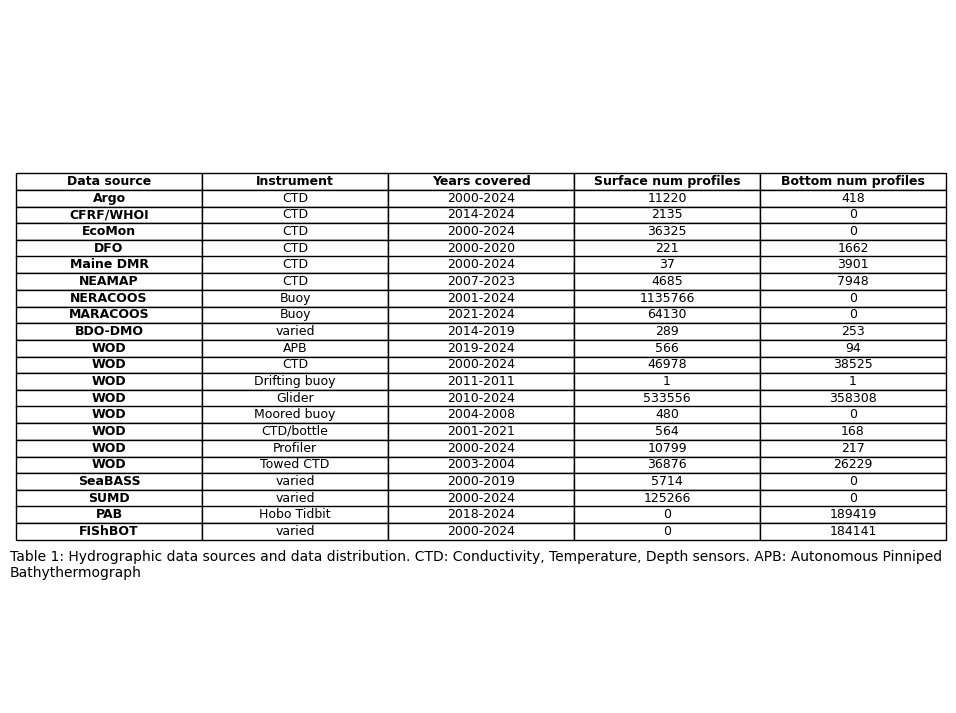

In [4]:
df=df_surf
dic_surf = {'argo':{'numprof_bot':len(df_bot[df_bot.source=='argo']),'long_name':'Argo','numprof':len(df[df.source=='argo']),'instrument':'CTD','doi':'ERDDAP','years':f'{int(df[df.source=='argo'].year.min())}-{int(df[df.source=='argo'].year.max())}'},
      'cfrf':{'numprof_bot':len(df_bot[df_bot.source=='cfrf']),'long_name':'CFRF/WHOI','numprof':len(df[df.source=='cfrf']),'instrument':'CTD','doi':'ERDDAP','years':f'{int(df[df.source=='cfrf'].year.min())}-{int(df[df.source=='cfrf'].year.max())}'},
      'ecomon':{'numprof_bot':len(df_bot[df_bot.source=='ecomon']),'long_name':'EcoMon','numprof':len(df[df.source=='ecomon']),'instrument':'CTD','doi':'ERDDAP','years':f'{int(df[df.source=='ecomon'].year.min())}-{int(df[df.source=='ecomon'].year.max())}'},
       'dfo':{'numprof_bot':len(df_bot[df_bot.source=='dfo']),'long_name':'DFO','numprof':len(df[df.source=='dfo']),'instrument':'CTD','doi':'ERDDAP','years':f'{int(df[df.source=='dfo'].year.min())}-{int(df[df.source=='dfo'].year.max())}'},
       'metrawl':{'numprof_bot':len(df_bot[df_bot.source=='metrawl']),'long_name':'Maine DMR','numprof':len(df[df.source=='metrawl']),'instrument':'CTD','doi':'','years':f'{int(df[df.source=='metrawl'].year.min())}-{int(df[df.source=='metrawl'].year.max())}'},
       'neamap':{'numprof_bot':len(df_bot[df_bot.source=='neamap']),'long_name':'NEAMAP','numprof':len(df[df.source=='neamap']),'instrument':'CTD','doi':'By request only','years':f'{int(df[df.source=='neamap'].year.min())}-{int(df[df.source=='neamap'].year.max())}'},
       'neracoos':{'numprof_bot':len(df_bot[df_bot.source=='neracoos']),'long_name':'NERACOOS','numprof':len(df[df.source=='neracoos']),'instrument':'Buoy','doi':'ERDDAP','years':f'{int(df[df.source=='neracoos'].year.min())}-{int(df[df.source=='neracoos'].year.max())}'},
       'maracoos':{'numprof_bot':int(len(df_bot[df_bot.source=='maracoos'])),'long_name':'MARACOOS','numprof':len(df[df.source=='maracoos']),'instrument':'Buoy','doi':'ERDDAP','years':f'{int(df[df.source=='maracoos'].year.min())}-{int(df[df.source=='maracoos'].year.max())}'},
       'bcodmo':{'numprof_bot':len(df_bot[df_bot.source=='bcodmo']),'long_name':'BDO-DMO','numprof':len(df[df.source=='bcodmo']),'instrument':'varied','doi':'ERDDAP','years':f'{int(df[df.source=='bcodmo'].year.min())}-{int(df[df.source=='bcodmo'].year.max())}'},
       'wod_apb':{'numprof_bot':len(df_bot[df_bot.source=='wod_apb']),'long_name':'WOD','numprof':len(df[df.source=='wod_apb']),'instrument':'APB','doi':'WOD search & select','years':f'{int(df[df.source=='wod_apb'].year.min())}-{int(df[df.source=='wod_apb'].year.max())}'},
       'wod_ctd':{'numprof_bot':len(df_bot[df_bot.source=='wod_ctd']),'long_name':'WOD','numprof':len(df[df.source=='wod_ctd']),'instrument':'CTD','doi':'WOD search & select','years':f'{int(df[df.source=='wod_ctd'].year.min())}-{int(df[df.source=='wod_ctd'].year.max())}'},
       'wod_drb':{'numprof_bot':len(df_bot[df_bot.source=='wod_drb']),'long_name':'WOD','numprof':len(df[df.source=='wod_drb']),'instrument':'Drifting buoy','doi':'WOD search & select','years':f'{int(df[df.source=='wod_drb'].year.min())}-{int(df[df.source=='wod_drb'].year.max())}'},
       'wod_gld':{'numprof_bot':len(df_bot[df_bot.source=='wod_gld']),'long_name':'WOD','numprof':len(df[df.source=='wod_gld']),'instrument':'Glider','doi':'WOD search & select','years':f'{int(df[df.source=='wod_gld'].year.min())}-{int(df[df.source=='wod_gld'].year.max())}'},
       'wod_mrb':{'numprof_bot':len(df_bot[df_bot.source=='wod_mrb']),'long_name':'WOD','numprof':len(df[df.source=='wod_mrb']),'instrument':'Moored buoy','doi':'WOD search & select','years':f'{int(df[df.source=='wod_mrb'].year.min())}-{int(df[df.source=='wod_mrb'].year.max())}'},
       'wod_osd':{'numprof_bot':len(df_bot[df_bot.source=='wod_osd']),'long_name':'WOD','numprof':len(df[df.source=='wod_osd']),'instrument':'CTD/bottle','doi':'WOD search & select','years':f'{int(df[df.source=='wod_osd'].year.min())}-{int(df[df.source=='wod_osd'].year.max())}'},
       'wod_pfl':{'numprof_bot':len(df_bot[df_bot.source=='wod_pfl']),'long_name':'WOD','numprof':len(df[df.source=='wod_pfl']),'instrument':'Profiler','doi':'WOD search & select','years':f'{int(df[df.source=='wod_pfl'].year.min())}-{int(df[df.source=='wod_pfl'].year.max())}'},
       'wod_uor':{'numprof_bot':len(df_bot[df_bot.source=='wod_uor']),'long_name':'WOD','numprof':len(df[df.source=='wod_uor']),'instrument':'Towed CTD','doi':'WOD search & select','years':f'{int(df[df.source=='wod_uor'].year.min())}-{int(df[df.source=='wod_uor'].year.max())}'},
       #'pioneerarray':{'numprof_bot':len(df_bot[df_bot.source=='pioneerarray']),'long_name':'Pioneer Array','numprof':len(df[df.source=='pioneerarray']),'instrument':'CTD','doi':'ERDDAP','years':f'{int(df[df.source=='pioneerarray'].year.min())}-{int(df[df.source=='pioneerarray'].year.max())}'},
       'seabass':{'numprof_bot':len(df_bot[df_bot.source=='seabass']),'long_name':'SeaBASS','numprof':len(df[df.source=='seabass']),'instrument':'varied','doi':'SeaBASS','years':f'{int(df[df.source=='seabass'].year.min())}-{int(df[df.source=='seabass'].year.max())}'},
       'sumd':{'numprof_bot':len(df_bot[df_bot.source=='sumd']),'long_name':'SUMD','numprof':len(df[df.source=='sumd']),'instrument':'varied','doi':'','years':f'{int(df[df.source=='sumd'].year.min())}-{int(df[df.source=='sumd'].year.max())}'},
       'pam': {'numprof_bot':len(df_bot[df_bot.source=='pam']),'long_name':'PAB','numprof':len(df[df.source=='pam']),'instrument':'Hobo Tidbit','doi':'','years':f'{int(df_bot[df_bot.source=='pam'].year.min())}-{int(df_bot[df_bot.source=='pam'].year.max())}'},
       'FIShBOT': {'numprof_bot':len(df_bot[df_bot.source=='fishbot']),'long_name':'FIShBOT','numprof':len(df[df.source=='fishbot']),'instrument':'varied','doi':'10.5281/zenodo.22168636','years':f'{int(df_bot[df_bot.source=='fishbot'].year.min())}-{int(df_bot[df_bot.source=='fishbot'].year.max())}'},

      }
fullsrc=[v['long_name'] for v in dic_surf.values()]
instrument=[v['instrument'] for v in dic_surf.values()]
doi = [v['doi'] for v in dic_surf.values()]
leng = [v['numprof'] for v in dic_surf.values()]
leng_bot = [v['numprof_bot'] for v in dic_surf.values()]
yrs = [v['years'] for v in dic_surf.values()]

dd = pd.DataFrame({'Data source':fullsrc,'Instrument':instrument,'Years covered':yrs,'Surface num profiles':leng,'Bottom num profiles':leng_bot}).set_index('Data source')
dd=dd.reset_index()

fig, ax = plt.subplots(figsize=(12, 9))
ax.axis('off')  # Hide axes
# Add table
table = ax.table(
    cellText=dd.values,
    colLabels=dd.columns,
    cellLoc='center',
    loc='center'
)


plt.figtext(0.12, 0.25, "Table 1: Hydrographic data sources and data distribution. CTD: Conductivity, Temperature, Depth sensors. APB: Autonomous Pinniped \nBathythermograph", ha="left", fontsize=10)
#make first row bold
for key, cell in table.get_celld().items():
    row, col = key
    if row == 0:  # header row
        cell.set_text_props(weight='bold')
#make first column bold
for key, cell in table.get_celld().items():
    row, col = key
    if col == 0 and row > 0:  # skip header since it's already bold
        cell.set_text_props(weight='bold')
plt.savefig(os.path.join(base_dir,'FIGURES','DP_table1.jpg'), dpi=900,bbox_inches='tight')


## Figure 2
Figure 2 is created in a google slide, so no code is available here.

## Figure 3 
Plot surface data density

C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3631164119.py:37: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmax=10,vmin=1)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3631164119.py:37: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmax=10,vmin=1)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3631164119.py:37: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmax=10,vmin=1)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3631164119.py:37: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmax=10,vmin=1)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3631164119.py:37: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.

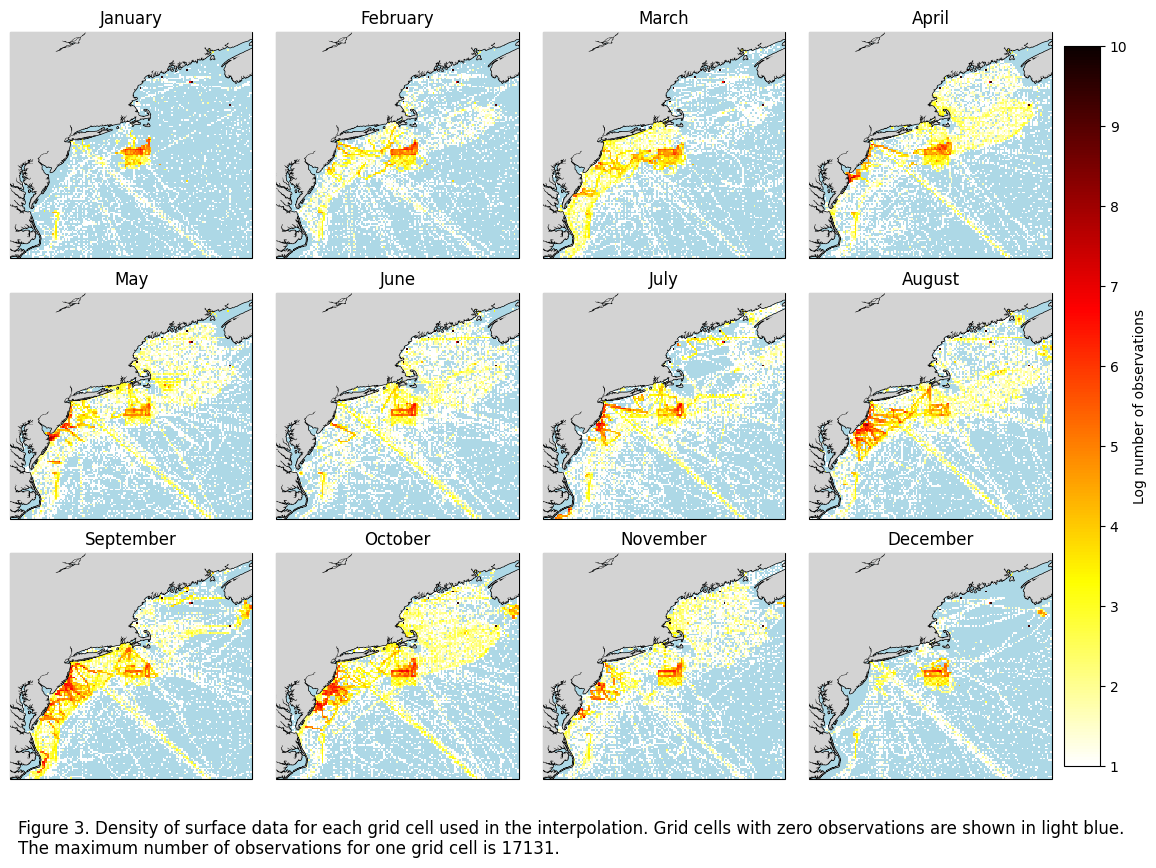

In [5]:
df = df_surf
numobs=[]
for x in range(1,13):
    sub=df[df.month==x]
    step = 1/12
    xx = np.arange(34.41, 46.36 + step / 2, step)
    yy = np.arange(-77.68, -63.59 + step / 2, step)
    dx = xx[1] - xx[0]
    dy = yy[1] - yy[0]
    
    x_edges = np.concatenate(([xx[0] - dx/2], xx + dx/2))
    y_edges = np.concatenate(([yy[0] - dy/2], yy + dy/2))
    
    H, _, _ = np.histogram2d(
        sub.latitude.values,
        sub.longitude.values,
        bins=[x_edges, y_edges]
    )
    numobs.append(H)

cmap = plt.cm.hot_r
cmap.set_bad(color='lightblue')   # color for zero-count cells

X_edges, Y_edges = np.meshgrid(x_edges, y_edges)

#get max num of obs
ma=[]
for x in range(12):
    ma.append(numobs[x].max())
    
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    sub=df[df.month==x+1]
    H_masked = np.ma.masked_where(numobs[x] == 0, numobs[x])
    im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmax=10,vmin=1)
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = f"Figure 3. Density of surface data for each grid cell used in the interpolation. Grid cells with zero observations are shown in light blue.\nThe maximum number of observations for one grid cell is {int(max(ma))}."
plt.figtext(0.13, 0.09, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Log number of observations',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig3.jpg'), dpi=600,bbox_inches='tight')

## Figure 4
Plot bottom data density

C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3944976565.py:35: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmin=1,vmax=10)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3944976565.py:35: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmin=1,vmax=10)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3944976565.py:35: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmin=1,vmax=10)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3944976565.py:35: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmin=1,vmax=10)
C:\Users\haley.synan\AppData\Local\Temp\ipykernel_8604\3944976565.py:35: RuntimeWarning: divide by zero encountered in log
  im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.

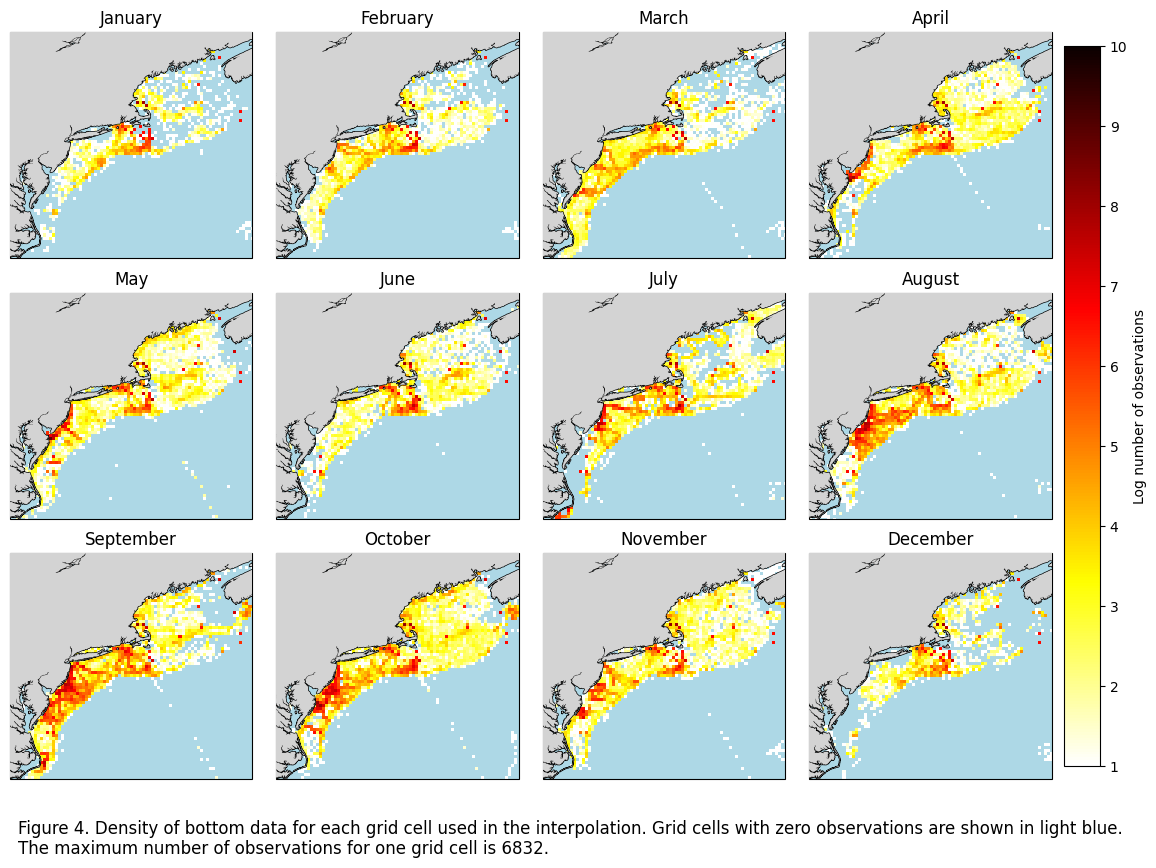

In [6]:
df = df_bot
numobs=[]
for x in range(1,13):
    sub=df[df.month==x]
    xx = np.linspace(34.41,46.36,80)
    yy = np.linspace(-77.68,-63.59,94)
    dx = xx[1] - xx[0]
    dy = yy[1] - yy[0]
    
    x_edges = np.concatenate(([xx[0] - dx/2], xx + dx/2))
    y_edges = np.concatenate(([yy[0] - dy/2], yy + dy/2))
    
    H, _, _ = np.histogram2d(
        sub.latitude.values,
        sub.longitude.values,
        bins=[x_edges, y_edges]
    )
    numobs.append(H)

cmap = plt.cm.hot_r
cmap.set_bad(color='lightblue')   # color for zero-count cells

X_edges, Y_edges = np.meshgrid(x_edges, y_edges)
#get max num of obs
ma=[]
for x in range(12):
    ma.append(numobs[x].max())
    
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    sub=df[df.month==x+1]
    H_masked = np.ma.masked_where(numobs[x] == 0, numobs[x])
    im=ax.pcolormesh(Y_edges, X_edges, np.log(H_masked.T), cmap=cmap,vmin=1,vmax=10)
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = f"Figure 4. Density of bottom data for each grid cell used in the interpolation. Grid cells with zero observations are shown in light blue.\nThe maximum number of observations for one grid cell is {int(max(ma))}."
plt.figtext(0.13, 0.09, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Log number of observations',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig4.jpg'), dpi=600,bbox_inches='tight')

## Figure 5
Plot monthly interpolations for surface CT

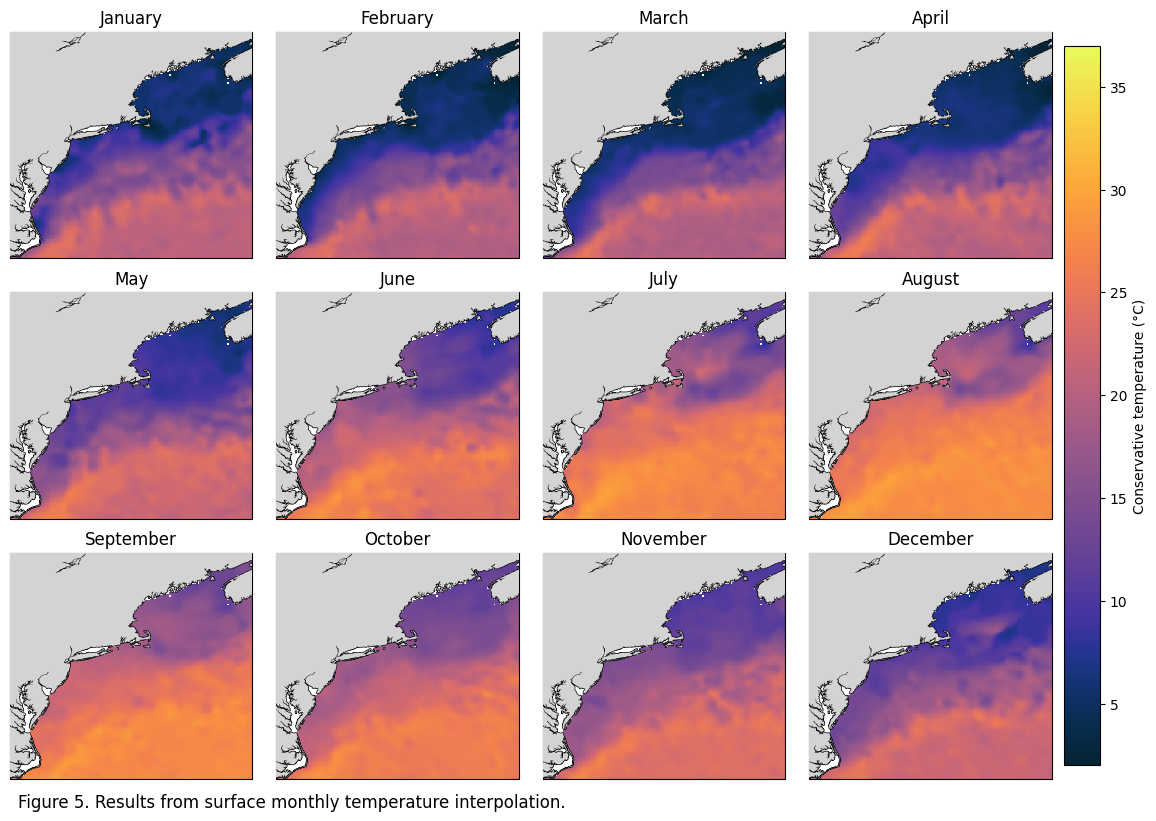

In [7]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    #im=ax.scatter(data_surf.longitude,data_surf.latitude,c=data_surf[f'CT{calendar.month_name[x+1]}'],cmap=cm.cm.thermal,vmin=2, vmax=37)
    im=ax.pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.CT[x],cmap=cm.cm.thermal,vmin=2, vmax=37)
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])

fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Figure 5. Results from surface monthly temperature interpolation."
plt.figtext(0.13, 0.13, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Conservative temperature (°C)',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig5.jpg'), dpi=600,bbox_inches='tight')

## Figure 6
Plot monthly interpolations for surface SA

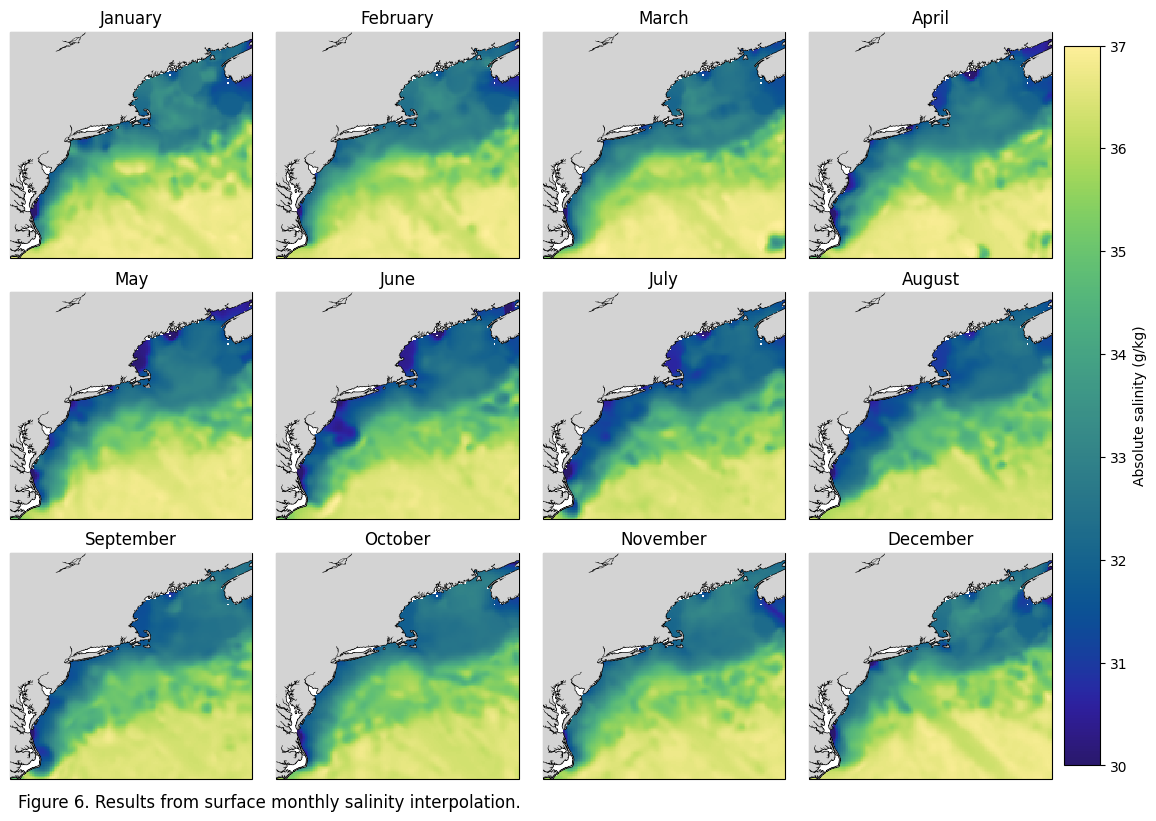

In [8]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    #im=ax.scatter(data_surf.longitude,data_surf.latitude,c=data_surf[f'SA{calendar.month_name[x+1]}'],cmap=cm.cm.haline,vmin=30, vmax=37)
    im=ax.pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.SA[x],cmap=cm.cm.haline,vmin=30, vmax=37)
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])

fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Figure 6. Results from surface monthly salinity interpolation."
plt.figtext(0.13, 0.13, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Absolute salinity (g/kg)',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig6.jpg'), dpi=600,bbox_inches='tight')

## Table 2
Surface: Lists the global RMSE from the interpolation and converts to MAPE, with color coded columns based on MAPE (<5%, 5-10%, 10-20%, >20%).

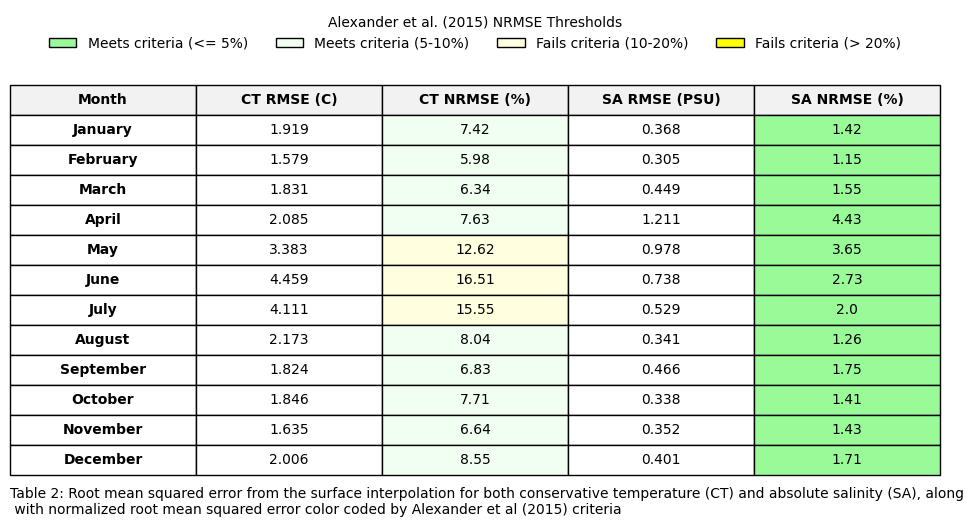

In [9]:
data = df_surf
rmse_ct = pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\FINAL\RMSE_CT_surface.csv")[12:24]
rmse_sa = pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\FINAL\RMSE_SA_surface.csv")#[12:24]
month=['January','February','March','April','May','June','July','August','September','October','November','December']
ct_rmse = rmse_ct['2'].tolist()
sa_rmse = rmse_sa['2'].tolist()

ct_norm_r=[]
for xx in range(1,13):
    d1=data[data.month==xx].CT.dropna() #RANGE OF ORIGINAL DATA
    r1= ct_rmse[xx-1]
    rangee=d1.max()-d1.min()
    ct_norm_r.append(round((r1/rangee)*100,2))

sa_norm_r=[]
for xx in range(1,13):
    d1= data[data.month==xx].CT.dropna()
    r1= sa_rmse[xx-1]
    rangee=d1.max()-d1.min()
    sa_norm_r.append(round((r1/rangee)*100,2))

table1=pd.DataFrame({'Month':month,'CT RMSE (C)':[round(num, 3) for num in ct_rmse],'CT NRMSE (%)':ct_norm_r,'SA RMSE (PSU)':[round(num, 3) for num in sa_rmse],'SA NRMSE (%)':sa_norm_r})

# 1. Define your data colors to match your logic
colors = {
    'Meets criteria (<= 5%)': 'palegreen',
    'Meets criteria (5-10%)': 'honeydew',
    'Fails criteria (10-20%)': 'lightyellow',
    'Fails criteria (> 20%)': 'yellow'
}

def get_color(val):
    if val <= 5: return 'palegreen'
    elif 5 < val <= 10: return 'honeydew'
    elif 10 < val <= 20: return 'lightyellow'
    else: return 'yellow'

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust size as needed
ax.axis('off')

# 3. Create the Table
# Cell colors need to be a matrix matching the shape of your dataframe
cell_colors = []
for i, row in table1.iterrows():
    row_colors = []
    for col in table1.columns:
        if col in ['CT NRMSE (%)', 'SA NRMSE (%)']:
            row_colors.append(get_color(row[col]))
        else:
            row_colors.append('white') # Default background
    cell_colors.append(row_colors)

the_table = ax.table(cellText=table1.values, 
                     colLabels=table1.columns, 
                     cellColours=cell_colors,
                     loc='center',
                     cellLoc='center')
# --- Customizing Cells (Bolding & Coloring) ---
for (row, col), cell in the_table.get_celld().items():
    # 1. Bold the Header Row (row 0)
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_facecolor('#f2f2f2') # Light grey header
    
    # 2. Bold the First Column (col 0)
    elif col == 0:
        cell.get_text().set_weight('bold')

the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.8) # Stretch cells for readability

# 4. Add the Legend (The clean way)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l, edgecolor='black') for l, c in colors.items()]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=4, title="Alexander et al. (2015) NRMSE Thresholds", frameon=False)

# --- Caption (Bottom) ---
# ha='center' keeps it in the middle; y=0.05 places it near the very bottom
plt.text(-0.1, 0.02, "Table 2: Root mean squared error from the surface interpolation for both conservative temperature (CT) and absolute salinity (SA), along\n with normalized root mean squared error color coded by Alexander et al (2015) criteria", 
         ha='left', va='center', transform=ax.transAxes, 
         fontsize=10, color='black')

plt.savefig(os.path.join(base_dir,'FIGURES','DP_table2.jpg'), dpi=300, bbox_inches='tight')

## Table 3
Load reference climatologies (ie GLORYS12V1 data). In the reference data (ie sat_df), temperature is ```thetao``` and salinity is ```so```.
Run statistics (ie avg bias, rmse, MAPE, pearson correlation) to compare the interpolated and reference climatologies. 

In [ ]:
## Load data 
import rioxarray # Necessary to enable the .rio accessors
from shapely.geometry import mapping
import geopandas as gpd
import copernicusmarine
from sklearn.metrics import mean_absolute_percentage_error
ds=ds_surf
try: 
    sat_on = xr.open_dataset(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\CLIMATOLOGIES\GLORYS_2000_2024_surf_sat_on.nc")
    sat_off= xr.open_dataset(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\CLIMATOLOGIES\GLORYS_2000_2024_surf_sat_off.nc")
    sat_on=sat_on.regrid.linear(ds)
    sat_off=sat_off.regrid.linear(ds.drop_vars('spatial_ref'))
    shp = gpd.read_file(r'W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\SHAPEFILES\NES_5REGIONS.shp')
    shp['geometry'] = shp.geometry.buffer(0.2)
    shp.crs = "epsg:4326"
    
    ds = ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    ds.rio.write_crs("epsg:4326", inplace=True) # Example CRS, check your data source
    
    # Reproject the GeoDataFrame to match the xarray's CRS if necessary
    shp = shp.to_crs(ds.rio.crs)
    ds_on = ds.rio.clip(shp.geometry.values, shp.crs, drop=False)
    ds_off = np.isnan(ds_on) 
    ds_off =ds.where(ds_off, other=np.nan)
    print('local files found') 
except:
    print('local files not found... streaming from copernicusmarine')
    datasetid= 'cmems_mod_glo_phy_my_0.083deg_P1D-m'
    start_date = '2000-01-01'
    end_date = '2024-12-31'
    min_lat=34
    max_lat=46
    min_lon=-77
    max_lon=-63
    glorys = copernicusmarine.open_dataset(dataset_id = datasetid,
                                      start_datetime=start_date,
                                      end_datetime=end_date,
                                      minimum_latitude=min_lat,
                                      maximum_latitude=max_lat,
                                      minimum_longitude=min_lon,
                                      maximum_longitude=max_lon,
                                      variables=["thetao",'mlotst','so'])
    
    clima=glorys.groupby("time.month").mean()
    
    # create the mask 
    mask = clima['depth'] <= clima['mlotst']
    
    # apply mask
    masked_temp = clima['thetao'].where(mask)
    masked_sal = clima['so'].where(mask)
    
    # average along the depth dimension
    mld_avg_temp = masked_temp.mean(dim='depth', skipna=True)
    mld_avg_sal = masked_sal.mean(dim='depth', skipna=True)
    
    sat_ds = xr.merge([mld_avg_temp, mld_avg_sal])
    #sat= pd.read_csv(r'C:\Users\haley.synan\Documents\DATA\CLIMATOLOGIES\SATELLITE_DERIVED\NESCAPES_4km.csv')
    #sat_ds= sat.set_index(['latitude','longitude']).to_xarray()
    sat_ds=sat_ds.regrid.linear(ds)
    shp = gpd.read_file(r'W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\SHAPEFILES\NES_5REGIONS.shp')
    shp['geometry'] = shp.geometry.buffer(0.2)
    shp.crs = "epsg:4326"
    
    ds = ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    ds.rio.write_crs("epsg:4326", inplace=True) # Example CRS, check your data source
    
    # Reproject the GeoDataFrame to match the xarray's CRS if necessary
    shp = shp.to_crs(ds.rio.crs)
    ds_on = ds.rio.clip(shp.geometry.values, shp.crs, drop=False)
    ds_off = np.isnan(ds_on) 
    ds_off =ds.where(ds_off, other=np.nan)
    
    
    sat_ds = sat_ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    sat_ds.rio.write_crs("epsg:4326", inplace=True) # Example CRS, check your data source
    
    # Reproject the GeoDataFrame to match the xarray's CRS if necessary
    shp = shp.to_crs(sat_ds.rio.crs)
    sat_on = sat_ds.rio.clip(shp.geometry.values, shp.crs, drop=False)
    sat_off = np.isnan(sat_on) 
    sat_off =sat_ds.where(sat_off, other=np.nan)

In [ ]:
#THIS IS UPDATED USE THIS 

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

month = ['January','February','March','April','May','June','July','August','September','October','November','December']

# 1. Calculate the difference arrays for all 12 months at once
diff_ct_on = ds_on.CT - sat_on.thetao
diff_ct_off = ds_off.CT - sat_off.thetao
diff_sa_on = ds_on.SA - sat_on.so
diff_sa_off = ds_off.SA - sat_off.so

# 2. Vectorized Metric Calculations
# xarray will calculate the mean/corr over lat and lon, returning a 1D array of 12 months automatically

# --- CONSERVATIVE TEMPERATURE (CT) ONSHELF ---
ct_bias_on = diff_ct_on.mean(dim=['latitude', 'longitude']).round(3).values
ct_rmse_on = np.sqrt((diff_ct_on**2).mean(dim=['latitude', 'longitude'])).round(3).values
ct_corr_on = xr.corr(ds_on.CT, sat_on.thetao, dim=['latitude', 'longitude']).round(3).values
ct_mape_on = [round(calculate_mape(sat_on.thetao[x], ds_on.CT[x]), 3) for x in range(12)]

# --- CONSERVATIVE TEMPERATURE (CT) OFFSHELF ---
ct_bias_off = diff_ct_off.mean(dim=['latitude', 'longitude']).round(3).values
ct_rmse_off = np.sqrt((diff_ct_off**2).mean(dim=['latitude', 'longitude'])).round(3).values
ct_corr_off = xr.corr(ds_off.CT, sat_off.thetao, dim=['latitude', 'longitude']).round(3).values
ct_mape_off = [round(calculate_mape(sat_off.thetao[x], ds_off.CT[x]), 3) for x in range(12)]

# --- ABSOLUTE SALINITY (SA) ONSHELF ---
sa_bias_on = diff_sa_on.mean(dim=['latitude', 'longitude']).round(3).values
sa_rmse_on = np.sqrt((diff_sa_on**2).mean(dim=['latitude', 'longitude'])).round(3).values
sa_corr_on = xr.corr(ds_on.SA, sat_on.so, dim=['latitude', 'longitude']).round(3).values
sa_mape_on = [round(calculate_mape(sat_on.so[x], ds_on.SA[x]), 3) for x in range(12)]

# --- ABSOLUTE SALINITY (SA) OFFSHELF ---
sa_bias_off = diff_sa_off.mean(dim=['latitude', 'longitude']).round(3).values
sa_rmse_off = np.sqrt((diff_sa_off**2).mean(dim=['latitude', 'longitude'])).round(3).values
sa_corr_off = xr.corr(ds_off.SA, sat_off.so, dim=['latitude', 'longitude']).round(3).values
sa_mape_off = [round(calculate_mape(sat_off.so[x], ds_off.SA[x]), 3) for x in range(12)]


# 3. Build DataFrame
table3 = pd.DataFrame({
    'Month': month,
    'Avg Bias': ct_bias_on,
    'Avg Bias ': ct_bias_off,
    'RMSE': ct_rmse_on,
    'RMSE ': ct_rmse_off,
    'MAPE': ct_mape_on,
    'MAPE ': ct_mape_off,
    'Corr': ct_corr_on,
    'Corr ': ct_corr_off,
    ' Avg Bias': sa_bias_on,
    ' Avg Bias ': sa_bias_off,
    ' RMSE': sa_rmse_on,
    ' RMSE ': sa_rmse_off,
    ' MAPE': sa_mape_on,
    ' MAPE ': sa_mape_off,
    ' Corr': sa_corr_on,
    ' Corr ': sa_corr_off
})

# 4. Setup Plot
color_map = {
    'Month': 'white',
    'Avg Bias': 'lightcyan',
    'RMSE': 'lightcyan',
    'MAPE': 'lightcyan',
    'Corr': 'lightcyan',
    'Avg Bias ': 'cyan',
    'RMSE ': 'cyan',
    'MAPE ': 'cyan',
    'Corr ': 'cyan',
    ' Avg Bias': 'honeydew',
    ' RMSE': 'honeydew',
    ' MAPE': 'honeydew',
    ' Corr': 'honeydew',
    ' Avg Bias ': 'palegreen',
    ' RMSE ': 'palegreen',
    ' MAPE ': 'palegreen',
    ' Corr ': 'palegreen'
}

fig, ax = plt.subplots(figsize=(18, 7))
ax.axis('off')

# Use the columns directly
the_table = ax.table(cellText=table3.values, 
                     colLabels=table3.columns, 
                     loc='center', 
                     cellLoc='center')

# 5. Flat Formatting Loop
for (row, col), cell in the_table.get_celld().items():
    column_name = table3.columns[col]
    
    # Apply background color
    cell_color = color_map.get(column_name, 'white')
    cell.set_facecolor(cell_color)

    # Bold Header Row
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_facecolor('#f2f2f2') # Keep headers distinct
    
    # Bold First Column (Month)
    if col == 0:
        cell.get_text().set_weight('bold')

# 6. Final Polish
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.0, 2.2) # Adjust scale for JPG clarity

# Legend
legend_elements = [
    Patch(facecolor='lightcyan', label='CT Onshelf Metrics', edgecolor='0.3'),
    Patch(facecolor='honeydew', label='SA Onshelf Metrics', edgecolor='0.3'),
    Patch(facecolor='cyan', label='CT Offshelf Metrics', edgecolor='0.3'),
    Patch(facecolor='palegreen', label='SA Offshelf Metrics', edgecolor='0.3')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.03),
          ncol=2, frameon=False, prop={'weight': 'bold'})

# Caption
plt.text(0.0, -.03, "Table 3: Summary statistics for comparison of surface interpolated climatology to validation satellite climatology. Statistics include average bias (avg bias), root mean squared error (RMSE), mean \nabsolute percentage error (MAPE), and Pearson correlation (Corr). Values shown in green represent absolute salinity metrics, while values shown in blue represent conservative temperature metrics. ", 
         ha='left', transform=ax.transAxes, fontsize=10,)

# 7. Save as JPG
plt.savefig(os.path.join(base_dir,'FIGURES','DP_table3.jpg'), dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
import xarray as xr
import numpy as np
from scipy.stats import pearsonr

def xarray_pearson(da1, da2):
    """
    Calculates a single Pearson correlation and p-value for two xarray DataArrays,
    safely handling NaNs.
    """
    # 1. Extract values and flatten to 1D arrays
    v1 = da1.values.flatten()
    v2 = da2.values.flatten()
    
    # 2. Create a boolean mask where BOTH arrays have valid (non-NaN) data
    valid_mask = ~np.isnan(v1) & ~np.isnan(v2)
    
    # 3. Apply the mask to keep only valid pairs
    v1_clean = v1[valid_mask]
    v2_clean = v2[valid_mask]
    
    # 4. Check if we have enough data points left to correlate
    if len(v1_clean) < 2:
        return np.nan, np.nan
        
    # 5. Calculate correlation and p-value
    corr, p_value = pearsonr(v1_clean, v2_clean)
    
    return corr, p_value

all_greater_indices = [i for i, x in enumerate([xarray_pearson(ds_off.SA[x], sat_off.so[x])[1] for x in range(12)]) if x > 0.05]
print(f"Offshelf salinity indices that are statistically insignificant pearson correlation: {all_greater_indices}")
all_greater_indices = [i for i, x in enumerate([xarray_pearson(ds_off.CT[x], sat_off.thetao[x])[1] for x in range(12)]) if x > 0.05]
print(f"Offshelf temperature indices that are statistically insignificant pearson correlation: {all_greater_indices}")
all_greater_indices = [i for i, x in enumerate([xarray_pearson(ds_on.SA[x], sat_on.so[x])[1] for x in range(12)]) if x > 0.05]
print(f"Onshelf salinity indices that are statistically insignificant pearson correlation: {all_greater_indices}")
all_greater_indices = [i for i, x in enumerate([xarray_pearson(ds_on.CT[x], sat_on.thetao[x])[1] for x in range(12)]) if x > 0.05]
print(f"Onshelf temperature indices that are statistically insignificant pearson correlation: {all_greater_indices}")


## Figure 7 
Plot monthly interpolations for bottom CT

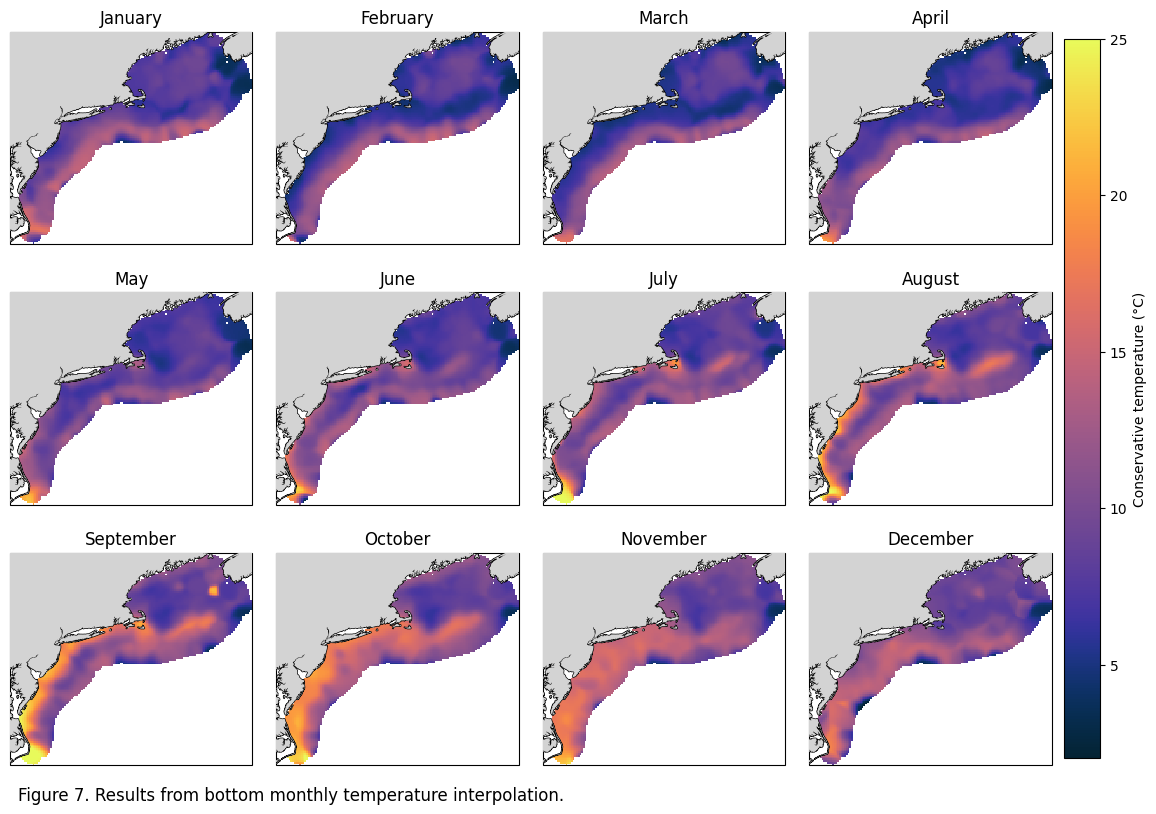

In [10]:
#figure 7
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    im=ax.pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.CT[x],cmap=cm.cm.thermal,vmin=2, vmax=25)
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])

fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Figure 7. Results from bottom monthly temperature interpolation."
plt.figtext(0.13, 0.13, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Conservative temperature (°C)',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig7.jpg'), dpi=600,bbox_inches='tight')

## Figure 8 
Plot monthly interpolations for bottom SA

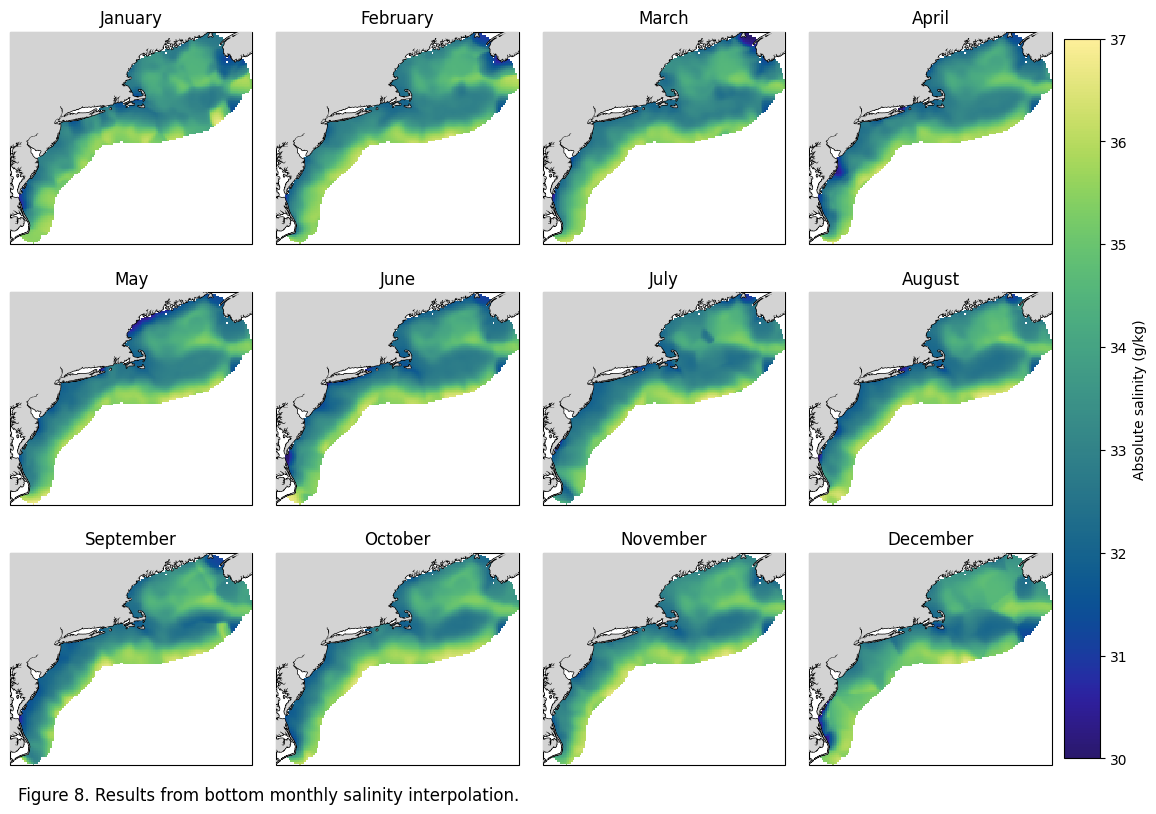

In [11]:
#figure 8
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    im=ax.pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.SA[x],cmap=cm.cm.haline,vmin=30, vmax=37)
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])

fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Figure 8. Results from bottom monthly salinity interpolation."
plt.figtext(0.13, 0.13, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Absolute salinity (g/kg)',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig8.jpg'), dpi=600,bbox_inches='tight')

## Table 4
Surface: Lists the global RMSE from the interpolation and converts to MAPE, with color coded columns based on MAPE (<5%, 5-10%, 10-20%, >20%).

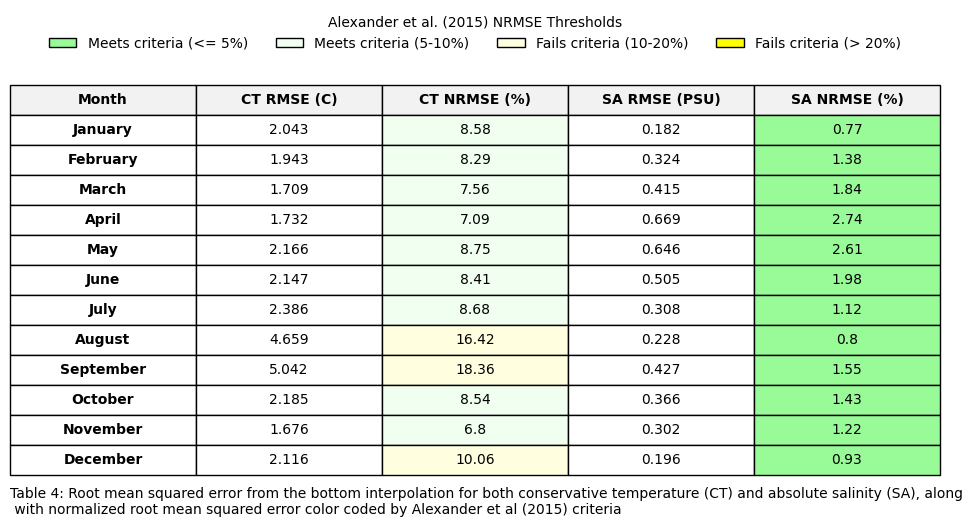

In [12]:
data = df_bot
rmse_ct = pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\FINAL\RMSE_CT_bottom.csv")#[12:24]
rmse_sa = pd.read_csv(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\FINAL\RMSE_SA_bottom.csv")[12:24]
month=['January','February','March','April','May','June','July','August','September','October','November','December']
ct_rmse = rmse_ct['2'].tolist()
sa_rmse = rmse_sa['2'].tolist()
ct_norm_r=[]
for xx in range(1,13):
    d1=data[data.month==xx].CT.dropna() #RANGE OF ORIGINAL DATA
    r1= ct_rmse[xx-1]
    rangee=d1.max()-d1.min()
    ct_norm_r.append(round((r1/rangee)*100,2))

sa_norm_r=[]
for xx in range(1,13):
    d1= data[data.month==xx].CT.dropna()
    r1= sa_rmse[xx-1]
    rangee=d1.max()-d1.min()
    sa_norm_r.append(round((r1/rangee)*100,2))

table1=pd.DataFrame({'Month':month,'CT RMSE (C)':[round(num, 3) for num in ct_rmse],'CT NRMSE (%)':ct_norm_r,'SA RMSE (PSU)':[round(num, 3) for num in sa_rmse],'SA NRMSE (%)':sa_norm_r})

# 1. Define your data colors to match your logic
colors = {
    'Meets criteria (<= 5%)': 'palegreen',
    'Meets criteria (5-10%)': 'honeydew',
    'Fails criteria (10-20%)': 'lightyellow',
    'Fails criteria (> 20%)': 'yellow'
}

def get_color(val):
    if val <= 5: return 'palegreen'
    elif 5 < val <= 10: return 'honeydew'
    elif 10 < val <= 20: return 'lightyellow'
    else: return 'yellow'

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust size as needed
ax.axis('off')

# 3. Create the Table
# Cell colors need to be a matrix matching the shape of your dataframe
cell_colors = []
for i, row in table1.iterrows():
    row_colors = []
    for col in table1.columns:
        if col in ['CT NRMSE (%)', 'SA NRMSE (%)']:
            row_colors.append(get_color(row[col]))
        else:
            row_colors.append('white') # Default background
    cell_colors.append(row_colors)

the_table = ax.table(cellText=table1.values, 
                     colLabels=table1.columns, 
                     cellColours=cell_colors,
                     loc='center',
                     cellLoc='center')
# --- Customizing Cells (Bolding & Coloring) ---
for (row, col), cell in the_table.get_celld().items():
    # 1. Bold the Header Row (row 0)
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_facecolor('#f2f2f2') # Light grey header
    
    # 2. Bold the First Column (col 0)
    elif col == 0:
        cell.get_text().set_weight('bold')

the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.2, 1.8) # Stretch cells for readability

# 4. Add the Legend (The clean way)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l, edgecolor='black') for l, c in colors.items()]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.1),
          ncol=4, title="Alexander et al. (2015) NRMSE Thresholds", frameon=False)

# --- Caption (Bottom) ---
plt.text(-0.1, 0.02, "Table 4: Root mean squared error from the bottom interpolation for both conservative temperature (CT) and absolute salinity (SA), along\n with normalized root mean squared error color coded by Alexander et al (2015) criteria", 
         ha='left', va='center', transform=ax.transAxes, 
         fontsize=10, color='black')
plt.savefig(os.path.join(base_dir,'FIGURES','DP_table4.jpg'), dpi=300, bbox_inches='tight')

## Table 5
Load reference climatologies (ie GLORYS12V1 data). In the reference data (ie sat_df), temperature is ```bottomT``` and salinity is ```so```.
Run statistics (ie avg bias, rmse, MAPE, pearson correlation) to compare the interpolated and reference climatologies. 

In [13]:
#open reference climatologies
try: 
    sat_on = xr.open_dataset(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\CLIMATOLOGIES\GLORYS_2000_2024_bot_sat_on.nc")
    sat_off= xr.open_dataset(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\CLIMATOLOGIES\GLORYS_2000_2024_bot_sat_off.nc")
    sat_on=sat_on.regrid.linear(ds)
    sat_off=sat_off.regrid.linear(ds.drop_vars('spatial_ref'))
    shp = gpd.read_file(r'W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\SHAPEFILES\NES_5REGIONS.shp')
    shp['geometry'] = shp.geometry.buffer(0.2)
    shp.crs = "epsg:4326"
    
    ds = ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    ds.rio.write_crs("epsg:4326", inplace=True) # Example CRS, check your data source
    
    # Reproject the GeoDataFrame to match the xarray's CRS if necessary
    shp = shp.to_crs(ds.rio.crs)
    ds_on = ds.rio.clip(shp.geometry.values, shp.crs, drop=False)
    ds_off = np.isnan(ds_on) 
    ds_off =ds.where(ds_off, other=np.nan)
    print('local files found') 
except:
    print('local files not found... streaming from copernicusmarine')
    datasetID = 'cmems_mod_glo_phy_my_0.083deg_P1M-m'
    
    sat_ds = copernicusmarine.open_dataset(dataset_id = datasetID,
                                       minimum_longitude=-77, maximum_longitude=-63,
                                       minimum_latitude=34,maximum_latitude=46,)
    #subset to NWA
    sat_ds = sat_ds.where((sat_ds.latitude > 34) & (sat_ds.latitude < 46) & (-63>sat_ds.longitude) & (-77< sat_ds.longitude),drop=True)
    sat_ds=sat_ds.sel(time=slice('2001-01-01', '2024-12-31'))
    sat_ds = sat_ds.groupby("time.month").mean(dim="time")
    
    bottom_salinity_clim = sat_ds.so.ffill(dim='depth').isel(depth=-1) #find max depth that isnt nan 
    land_mask = sat_ds.so.isel(depth=0, month=0).isnull()
    bottom_salinity_clim = bottom_salinity_clim.where(~land_mask)
    ss =bottom_salinity_clim.to_dataset()
    ss['bottomT'] = sat_ds.bottomT
    sat= pd.read_csv(r'C:\Users\haley.synan\Documents\DATA\CLIMATOLOGIES\SATELLITE_DERIVED\NESCAPES_4km.csv')
    sat_ds= sat.set_index(['latitude','longitude']).to_xarray()
    sat_ds=ss.regrid.linear(sat_ds)
    
    ds=ds_bot
    ds=ds.regrid.linear(sat_ds)
    shp = gpd.read_file(r'W:\nadata\PROJECTS\NESCAPES\SOURCE_DATA\SHAPEFILES\NES_5REGIONS.shp')
    shp['geometry'] = shp.geometry.buffer(0.2)
    shp.crs = "epsg:4326"
    
    ds = ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    ds.rio.write_crs("epsg:4326", inplace=True) # Example CRS, check your data source
    
    # Reproject the GeoDataFrame to match the xarray's CRS if necessary
    shp = shp.to_crs(ds.rio.crs)
    ds_on = ds.rio.clip(shp.geometry.values, shp.crs, drop=False)
    ds_off = np.isnan(ds_on) 
    ds_off =ds.where(ds_off, other=np.nan)
    
    
    sat_ds = sat_ds.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    sat_ds.rio.write_crs("epsg:4326", inplace=True) # Example CRS, check your data source
    
    # Reproject the GeoDataFrame to match the xarray's CRS if necessary
    shp = shp.to_crs(sat_ds.rio.crs)
    sat_on = sat_ds.rio.clip(shp.geometry.values, shp.crs, drop=False)
    sat_off = np.isnan(sat_on) 
    sat_off =sat_ds.where(sat_off, other=np.nan)

local files not found... streaming from copernicusmarine


INFO - 2026-09-04T14:09:37Z - Selected dataset version: "202311"
INFO - 2026-09-04T14:09:37Z - Selected dataset part: "default"


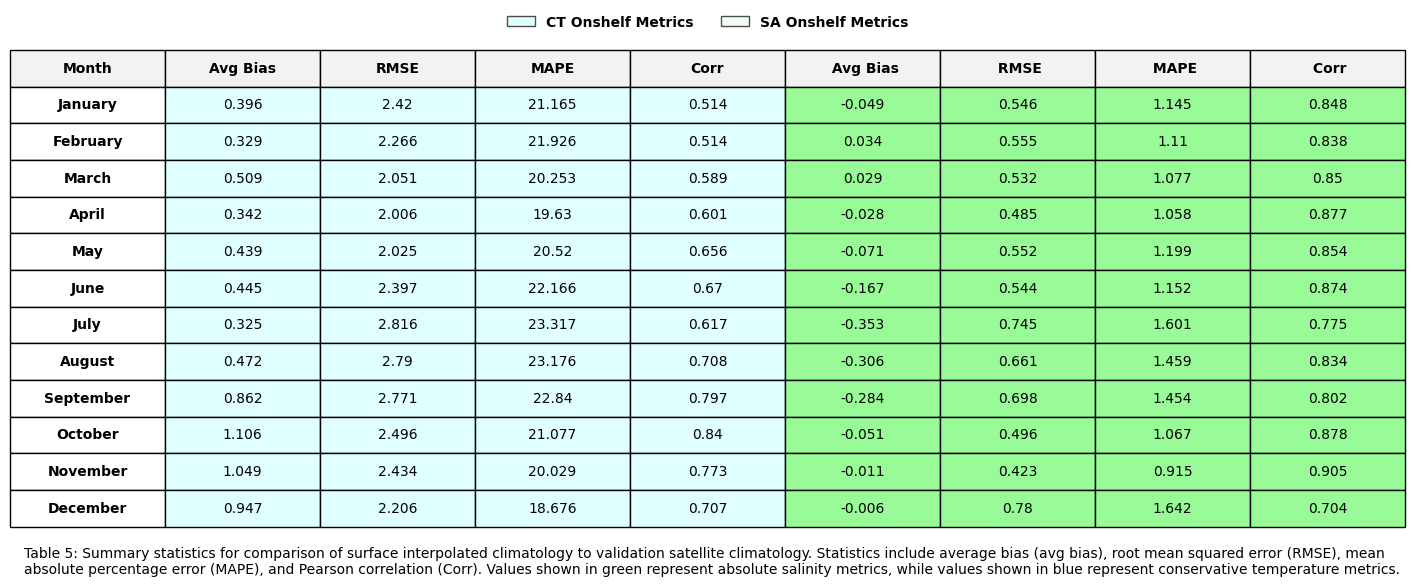

In [26]:
import rioxarray # Necessary to enable the .rio accessors
from shapely.geometry import mapping
import geopandas as gpd
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
month = ['January','February','March','April','May','June','July','August','September','October','November','December']

# 1. Calculate the difference arrays for all 12 months at once
diff_ct_on = ds_on.CT - sat_on.bottomT
diff_sa_on = ds_on.SA - sat_on.so

# 2. Get stats

# ONSHELF CT
ct_bias_on = diff_ct_on.mean(dim=['latitude', 'longitude']).round(3).values
ct_rmse_on = np.sqrt((diff_ct_on**2).mean(dim=['latitude', 'longitude'])).round(3).values
ct_corr_on = xr.corr(ds_on.CT, sat_on.bottomT, dim=['latitude', 'longitude']).round(3).values
ct_mape_on = [round(calculate_mape(sat_on.bottomT[x], ds_on.CT[x]), 3) for x in range(12)]


# ONSHELF SA
sa_bias_on = diff_sa_on.mean(dim=['latitude', 'longitude']).round(3).values
sa_rmse_on = np.sqrt((diff_sa_on**2).mean(dim=['latitude', 'longitude'])).round(3).values
sa_corr_on = xr.corr(ds_on.SA, sat_on.so, dim=['latitude', 'longitude']).round(3).values
sa_mape_on = [round(calculate_mape(sat_on.so[x], ds_on.SA[x]), 3) for x in range(12)]


# 4. BUILD DATAFRAME
# Now you can just pass the resulting arrays directly into Pandas
table3 = pd.DataFrame({
    'Month': month,
    'Avg Bias': ct_bias_on,
    'RMSE': ct_rmse_on,
    'MAPE': ct_mape_on,
    'Corr': ct_corr_on,
    ' Avg Bias': sa_bias_on,
    ' RMSE': sa_rmse_on,
    ' MAPE': sa_mape_on,
    ' Corr': sa_corr_on
})

color_map = {
    'Month': 'white',
    'Avg Bias': 'lightcyan',
    'RMSE': 'lightcyan',
    'MAPE': 'lightcyan',
    'Corr': 'lightcyan',
    ' Avg Bias': 'palegreen',
    ' RMSE': 'palegreen',
    ' MAPE': 'palegreen',
    ' Corr': 'palegreen',
}
from matplotlib.patches import Patch
# 2. Setup Plot
fig, ax = plt.subplots(figsize=(18, 7))
ax.axis('off')

# Use the columns directly since they are no longer nested tuples
the_table = ax.table(cellText=table3.values, 
                     colLabels=table3.columns, 
                     loc='center', 
                     cellLoc='center')

# 3. Flat Formatting Loop
for (row, col), cell in the_table.get_celld().items():
    column_name = table3.columns[col]
    
    # Apply background color
    cell_color = color_map.get(column_name, 'white')
    cell.set_facecolor(cell_color)

    # Bold Header Row
    if row == 0:
        cell.get_text().set_weight('bold')
        cell.set_facecolor('#f2f2f2') # Keep headers distinct
    
    # Bold First Column (Month)
    if col == 0:
        cell.get_text().set_weight('bold')

# 4. Final Polish
the_table.auto_set_font_size(False)
the_table.set_fontsize(10)
the_table.scale(1.0, 2.2) # Adjust scale for JPG clarity

# Legend
legend_elements = [
    Patch(facecolor='lightcyan', label='CT Onshelf Metrics', edgecolor='0.3'),
    Patch(facecolor='honeydew', label='SA Onshelf Metrics', edgecolor='0.3'),
    #Patch(facecolor='cyan', label='CT Offshelf Metrics', edgecolor='0.3'),
    #Patch(facecolor='palegreen', label='SA Offshelf Metrics', edgecolor='0.3')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.03),
          ncol=2, frameon=False, prop={'weight': 'bold'})

# Caption
plt.text(0.01, -.03, "Table 5: Summary statistics for comparison of surface interpolated climatology to validation satellite climatology. Statistics include average bias (avg bias), root mean squared error (RMSE), mean \nabsolute percentage error (MAPE), and Pearson correlation (Corr). Values shown in green represent absolute salinity metrics, while values shown in blue represent conservative temperature metrics. ", 
         ha='left', transform=ax.transAxes, fontsize=10,)

# 5. Save as JPG
plt.savefig(os.path.join(base_dir,'FIGURES','DP_table6.jpg'), dpi=600, bbox_inches='tight')
plt.show()

In [18]:
for x in range(12):
    corr_val, p_val = xarray_pearson(ds_on.SA[x], sat_on['so'][x])
    print(f"Correlation: {corr_val:.3f}, P-value: {p_val:.3e}")

NameError: name 'xarray_pearson' is not defined

## Figure 9 
Plot example maps of uncertainty metric

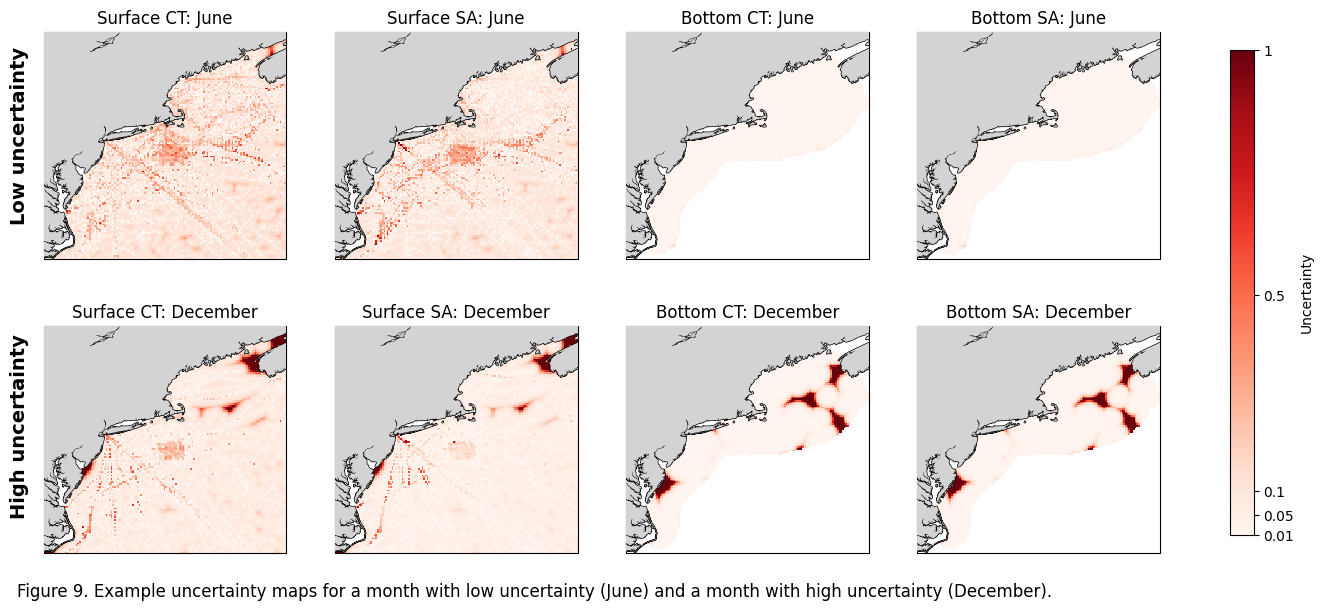

In [19]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(18, 7),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
im=ax[0,0].pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.CT_unc[5],vmin=0.01, vmax=1.0,cmap='Reds')
ax[0,0].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[0,0].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[0,0].set_title('Surface CT: June')
ax[0,0].set_extent([-77,-64.8,34.6,46])

ax[0,1].pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.SA_unc[5],vmin=0.01, vmax=1.0,cmap='Reds')
ax[0,1].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[0,1].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[0,1].set_title('Surface SA: June')
ax[0,1].set_extent([-77,-64.8,34.6,46])

ax[0,2].pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.CT_unc[5],vmin=0.01, vmax=1.0,cmap='Reds')
ax[0,2].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[0,2].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[0,2].set_title('Bottom CT: June')
ax[0,2].set_extent([-77,-64.8,34.6,46])

ax[0,3].pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.SA_unc[5],vmin=0.01, vmax=1.0,cmap='Reds')
ax[0,3].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[0,3].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[0,3].set_title('Bottom SA: June')
ax[0,3].set_extent([-77,-64.8,34.6,46])


ax[1,0].pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.CT_unc[11],vmin=0.01, vmax=1.0,cmap='Reds')
ax[1,0].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[1,0].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[1,0].set_title('Surface CT: December')
ax[1,0].set_extent([-77,-64.8,34.6,46])

ax[1,1].pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.SA_unc[11],vmin=0.01, vmax=1.0,cmap='Reds')
ax[1,1].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[1,1].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[1,1].set_title('Surface SA: December')
ax[1,1].set_extent([-77,-64.8,34.6,46])

ax[1,2].pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.CT_unc[11],vmin=0.01, vmax=1.0,cmap='Reds')
ax[1,2].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[1,2].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[1,2].set_title('Bottom CT: December')
ax[1,2].set_extent([-77,-64.8,34.6,46])

ax[1,3].pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.SA_unc[11],vmin=0.01, vmax=1.0,cmap='Reds')
ax[1,3].add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax[1,3].add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
ax[1,3].set_title('Bottom SA: December')
ax[1,3].set_extent([-77,-64.8,34.6,46])

cbar = fig.colorbar(im, ax=ax.ravel().tolist(), orientation='vertical', shrink=0.9, pad=0.05)
cbar.set_label('Uncertainty') # Optional: Add a label to your colorbar
cbar.set_ticks([0.01, 0.05, 0.1, 0.5, 1.0])
cbar.set_ticklabels(['0.01','0.05','0.1', '0.5','1'])

ax[0,0].text(-0.1, 0.15, 'Low uncertainty', 
             va='bottom', ha='center', rotation='vertical', 
             transform=ax[0,0].transAxes, fontsize=14, fontweight='bold')

# Add vertical text to the left of the bottom-left plot
ax[1,0].text(-0.1, 0.15, 'High uncertainty', 
             va='bottom', ha='center', rotation='vertical', 
             transform=ax[1,0].transAxes, fontsize=14, fontweight='bold')

#fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Figure 9. Example uncertainty maps for a month with low uncertainty (June) and a month with high uncertainty (December)."
plt.figtext(0.11, 0.06, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_fig9.jpg'), dpi=600,bbox_inches='tight')

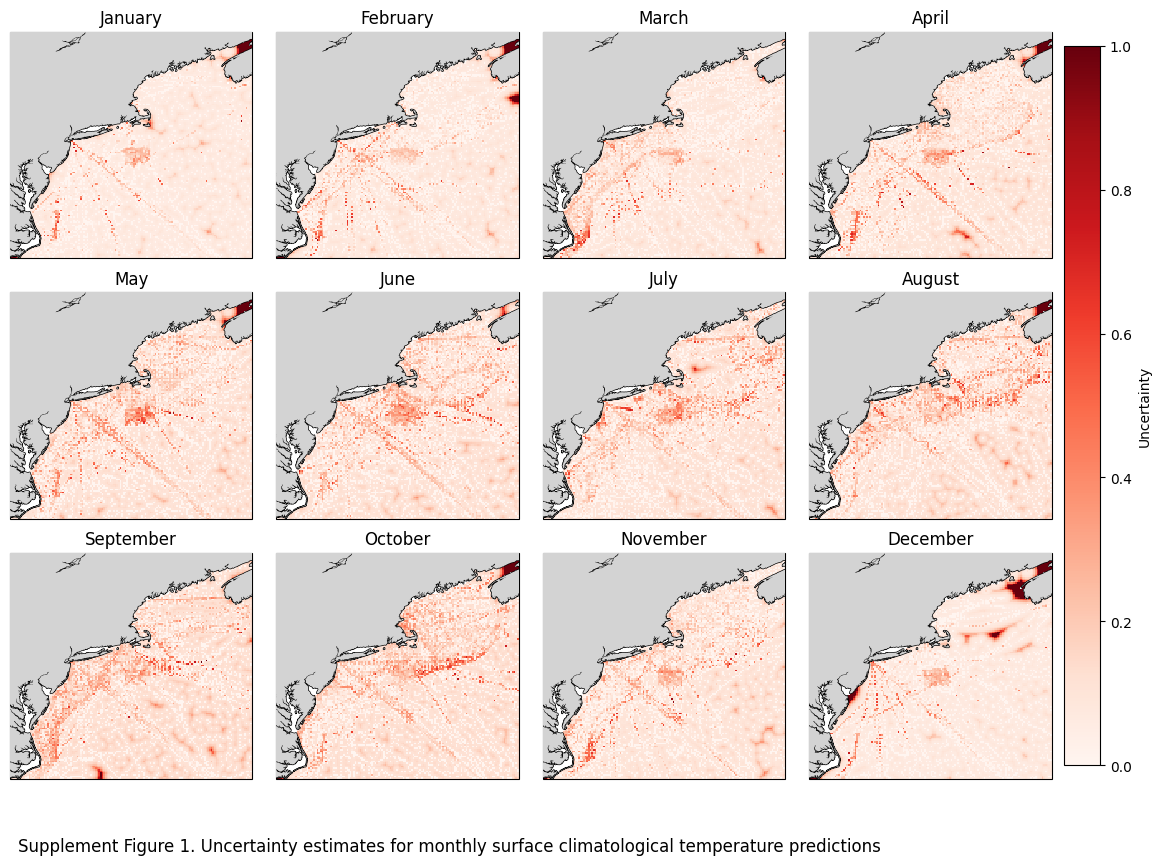

In [20]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    im=ax.pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.CT_unc[x],cmap='Reds')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Supplement Figure 1. Uncertainty estimates for monthly surface climatological temperature predictions"
plt.figtext(0.13, 0.09, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Uncertainty',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_sup1.jpg'), dpi=600,bbox_inches='tight')

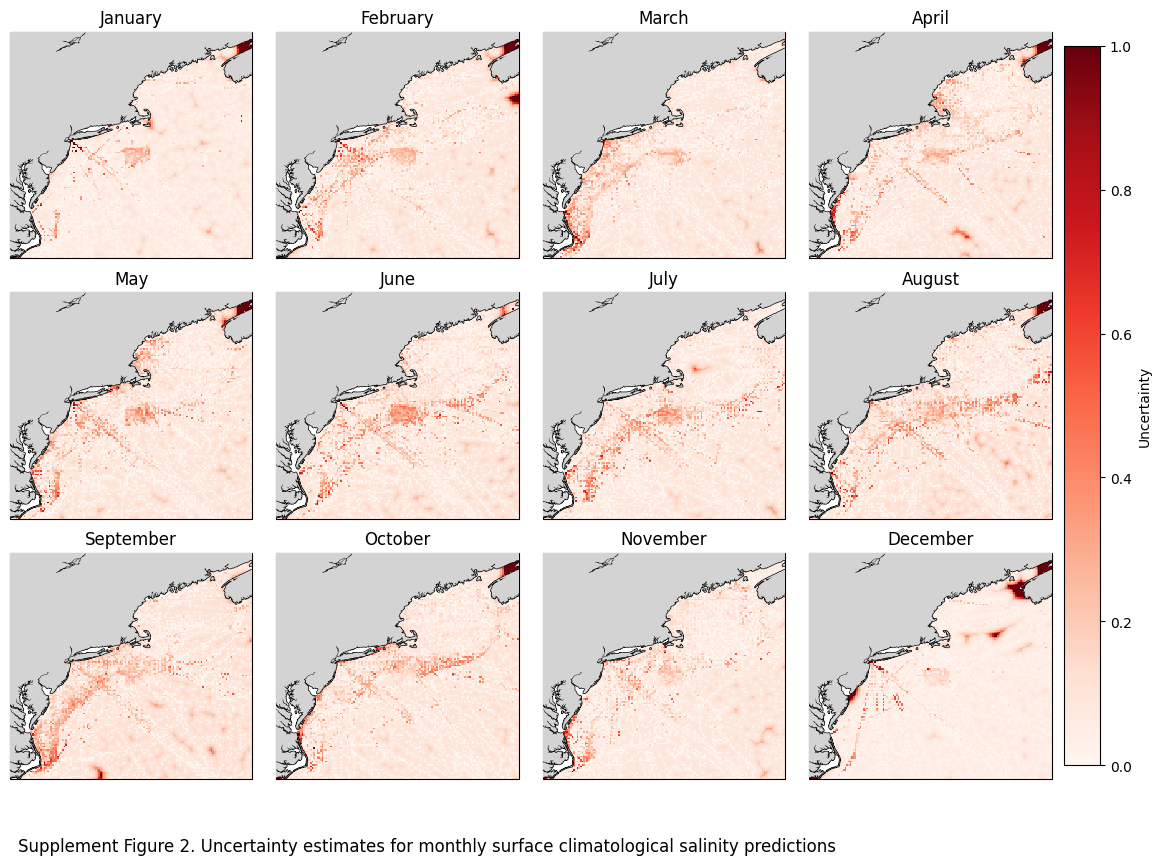

In [21]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    im=ax.pcolormesh(ds_surf.longitude,ds_surf.latitude,ds_surf.SA_unc[x],cmap='Reds')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Supplement Figure 2. Uncertainty estimates for monthly surface climatological salinity predictions"
plt.figtext(0.13, 0.09, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Uncertainty',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_sup2.jpg'), dpi=600,bbox_inches='tight')

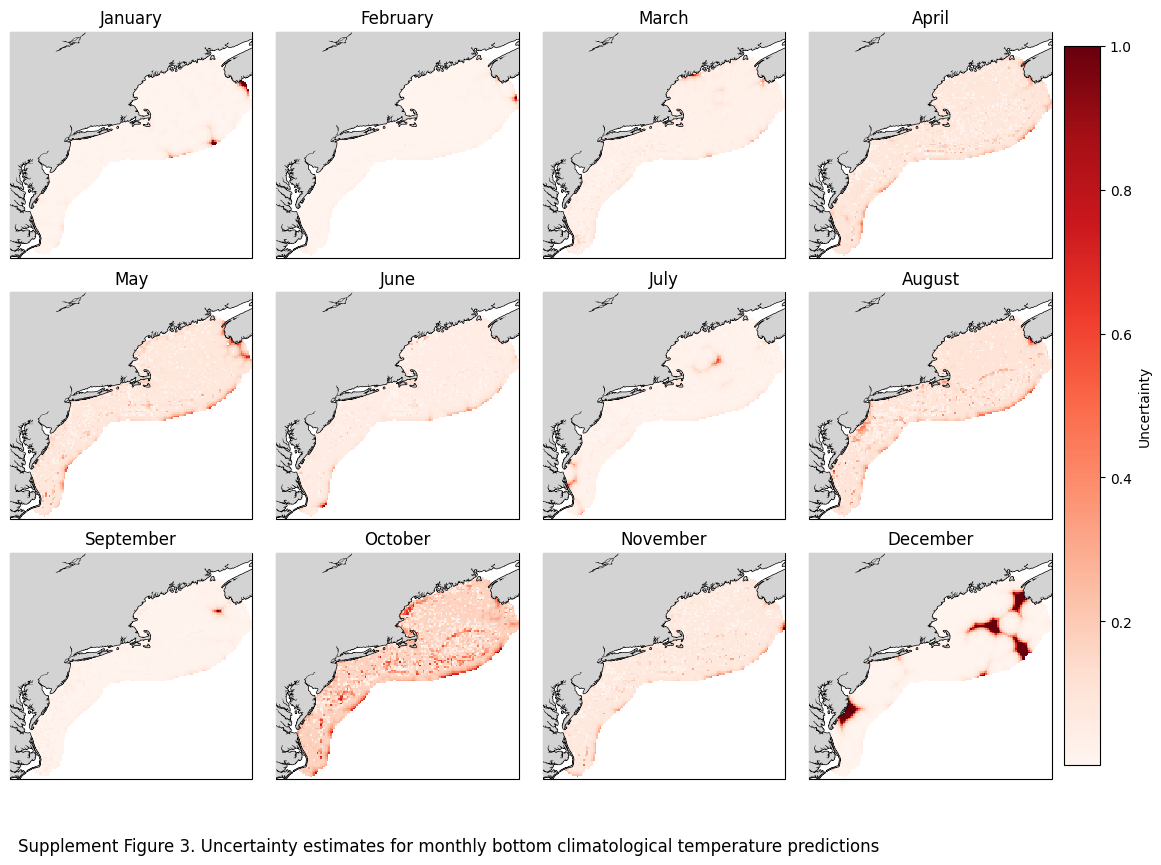

In [22]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    im=ax.pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.CT_unc[x],cmap='Reds')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Supplement Figure 3. Uncertainty estimates for monthly bottom climatological temperature predictions"
plt.figtext(0.13, 0.09, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Uncertainty',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_sup3.jpg'), dpi=600,bbox_inches='tight')

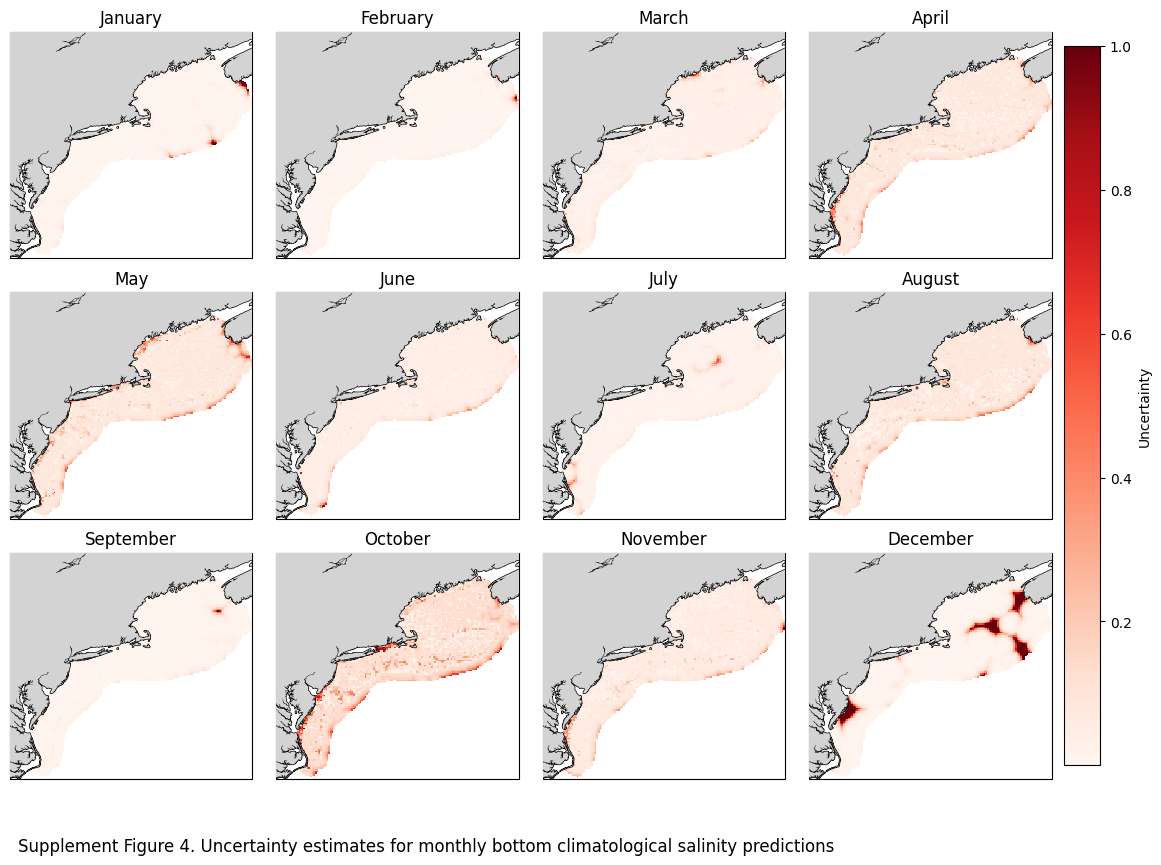

In [23]:
fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(16, 11),
                        subplot_kw={'projection': cartopy.crs.PlateCarree()})
axs_flat = axs.flatten()
for x, ax in enumerate(axs_flat):
    im=ax.pcolormesh(ds_bot.longitude,ds_bot.latitude,ds_bot.SA_unc[x],cmap='Reds')
    ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
    ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #
    ax.set_title(calendar.month_name[x+1])
    ax.set_extent([-77,-64.8,34.6,46])
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Supplement Figure 4. Uncertainty estimates for monthly bottom climatological salinity predictions"
plt.figtext(0.13, 0.09, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
cbar = fig.colorbar(im, ax=axs,label='Uncertainty',pad=0.01,shrink=0.85)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_sup4.jpg'), dpi=600,bbox_inches='tight')

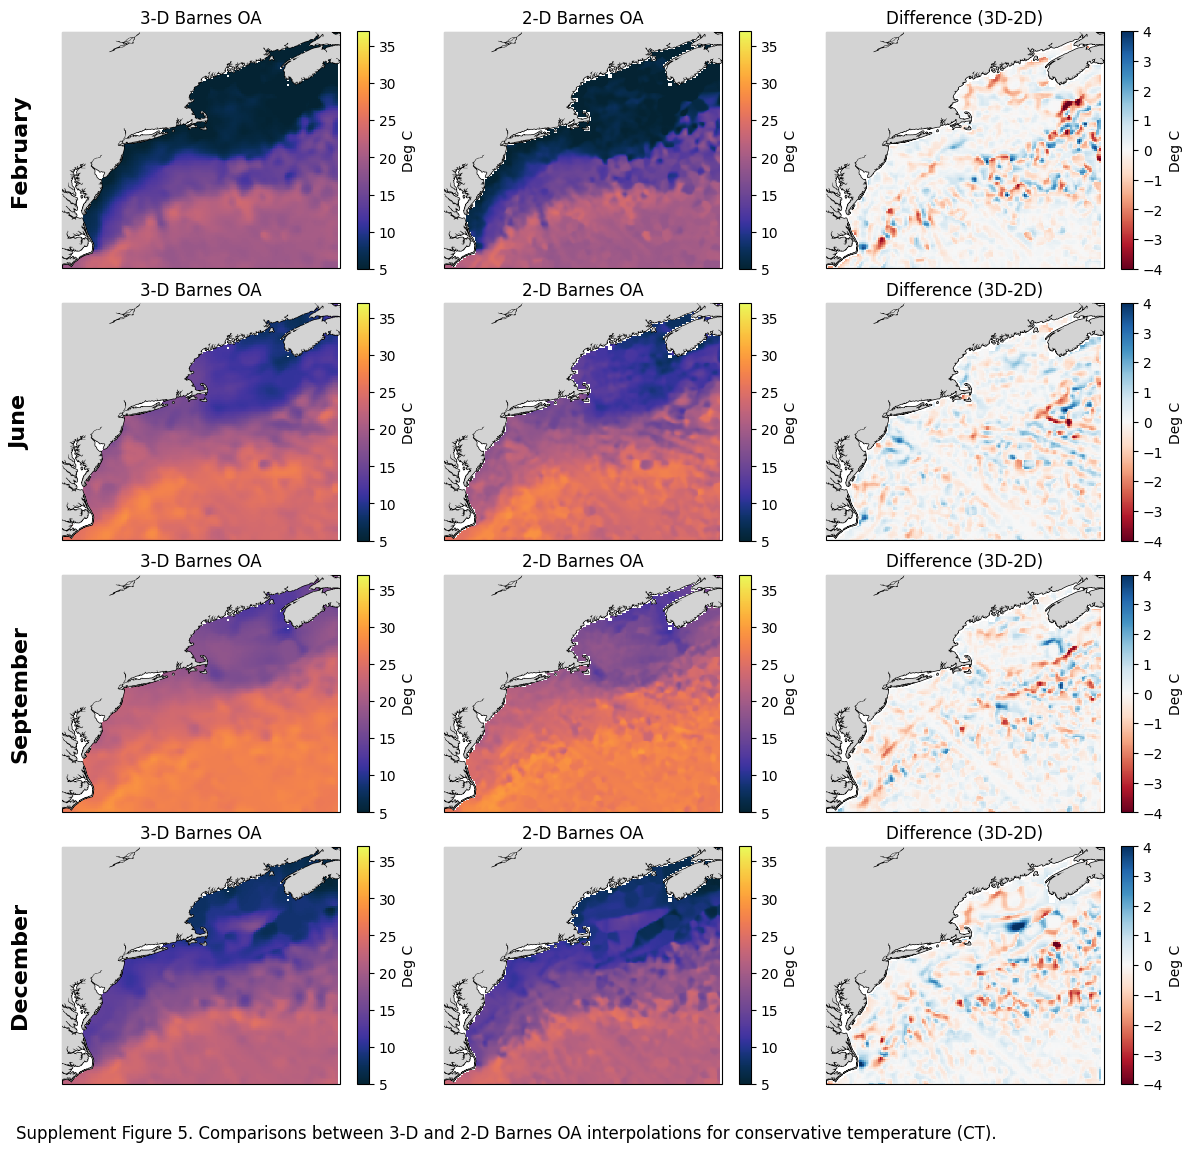

In [24]:
import cmocean
import cartopy
import matplotlib.pyplot as plt
import calendar
import xarray_regrid

ds= ds_surf
ds1 = xr.open_dataset(r"W:\nadata\PROJECTS\NESCAPES\PROCESSED_DATA\FINAL\hydrographic_climatology_surface_2000_2024_1.nc")
ds1 = ds1.drop_vars('spatial_ref')
# 2. Now run the regridder (the HDF error will be gone)
ds1_regridded = ds1.regrid.linear(ds)


fig, axes = plt.subplots(4, 3, figsize=(12,12), subplot_kw={'projection': cartopy.crs.PlateCarree()})
monthz = [1,5,8,11]
for x in range(4):
    # 2. Extract the 3 axes for the current row
    ax1, ax2, ax3 = axes[x]
    
    month_name = calendar.month_name[monthz[x]+1]
    
    im = ax1.pcolormesh(ds.longitude, ds.latitude, ds.CT[monthz[x]], cmap=cmocean.cm.thermal, vmin=5, vmax=37)
    ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1) 
    ax1.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') 
    ax1.set_extent([-77, -63.5, 34.5, 46])
    ax1.set_title('3-D Barnes OA')
    ax1.text(-0.15, 0.5, month_name, transform=ax1.transAxes, 
             fontsize=16, fontweight='bold', va='center', ha='center', rotation='vertical')
    
    im1 = ax2.pcolormesh(ds1.longitude, ds1.latitude, ds1.CT[monthz[x]], cmap=cmocean.cm.thermal, vmin=5, vmax=37)
    ax2.add_feature(cartopy.feature.COASTLINE, linewidth=1) 
    ax2.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') 
    ax2.set_extent([-77, -63.5, 34.5, 46])
    ax2.set_title('2-D Barnes OA')
    
    im2 = ax3.pcolormesh(ds.longitude, ds.latitude, ds.CT[monthz[x]].values - ds1_regridded.CT[monthz[x]], cmap='RdBu', vmin=-4, vmax=4)
    ax3.add_feature(cartopy.feature.COASTLINE, linewidth=1) 
    ax3.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') 
    ax3.set_extent([-77, -63.5, 34.5, 46])
    ax3.set_title('Difference (3D-2D)')
    
    fig.colorbar(im, ax=ax1, label='Deg C', shrink=0.7)
    fig.colorbar(im1, ax=ax2, label='Deg C', shrink=0.7)
    fig.colorbar(im2, ax=ax3, label='Deg C', shrink=0.7)

plt.tight_layout()
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Supplement Figure 5. Comparisons between 3-D and 2-D Barnes OA interpolations for conservative temperature (CT)."
plt.figtext(0.01, 0.01, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_sup5.jpg'), dpi=600,bbox_inches='tight')
plt.show()

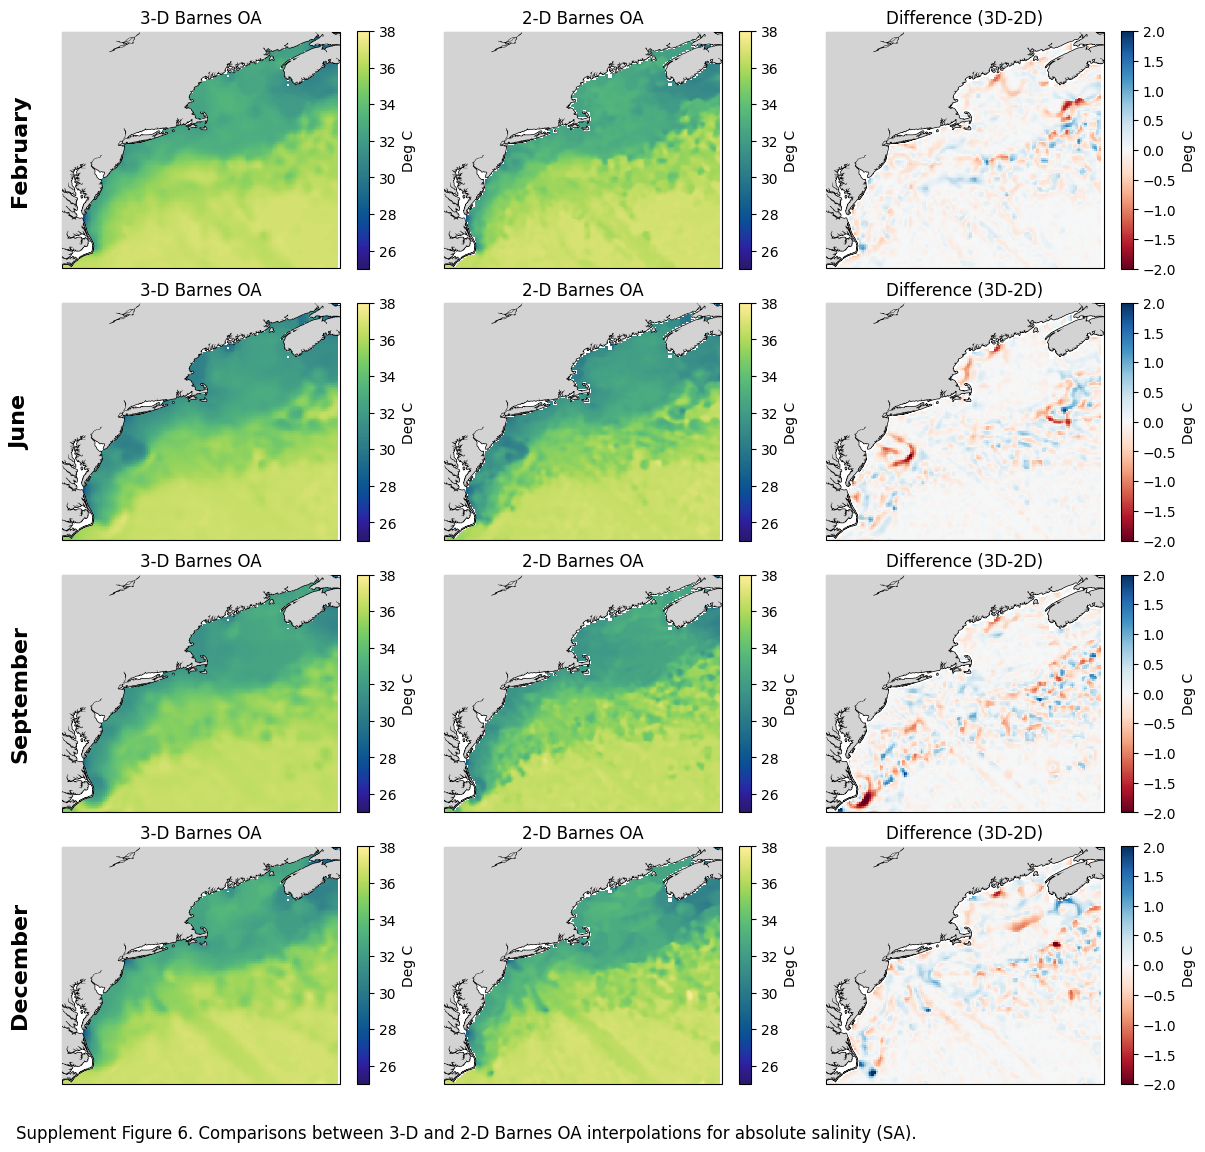

In [25]:
fig, axes = plt.subplots(4, 3, figsize=(12,12), subplot_kw={'projection': cartopy.crs.PlateCarree()})
monthz = [1,5,8,11]
for x in range(4):
    # 2. Extract the 3 axes for the current row
    ax1, ax2, ax3 = axes[x]
    
    month_name = calendar.month_name[monthz[x]+1]
    
    im = ax1.pcolormesh(ds.longitude, ds.latitude, ds.SA[monthz[x]], cmap=cmocean.cm.haline, vmin=25, vmax=38)
    ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1) 
    ax1.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') 
    ax1.set_extent([-77, -63.5, 34.5, 46])
    ax1.set_title('3-D Barnes OA')
    ax1.text(-0.15, 0.5, month_name, transform=ax1.transAxes, 
             fontsize=16, fontweight='bold', va='center', ha='center', rotation='vertical')
    
    im1 = ax2.pcolormesh(ds1.longitude, ds1.latitude, ds1.SA[monthz[x]], cmap=cmocean.cm.haline, vmin=25, vmax=38)
    ax2.add_feature(cartopy.feature.COASTLINE, linewidth=1) 
    ax2.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') 
    ax2.set_extent([-77, -63.5, 34.5, 46])
    ax2.set_title('2-D Barnes OA')
    
    im2 = ax3.pcolormesh(ds.longitude, ds.latitude, ds.SA[monthz[x]].values - ds1_regridded.SA[monthz[x]], cmap='RdBu', vmin=-2, vmax=2)
    ax3.add_feature(cartopy.feature.COASTLINE, linewidth=1) 
    ax3.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') 
    ax3.set_extent([-77, -63.5, 34.5, 46])
    ax3.set_title('Difference (3D-2D)')
    
    fig.colorbar(im, ax=ax1, label='Deg C', shrink=0.7)
    fig.colorbar(im1, ax=ax2, label='Deg C', shrink=0.7)
    fig.colorbar(im2, ax=ax3, label='Deg C', shrink=0.7)

plt.tight_layout()
fig.subplots_adjust(hspace=-0.2, wspace=0.1) 
caption_text = "Supplement Figure 6. Comparisons between 3-D and 2-D Barnes OA interpolations for absolute salinity (SA)."
plt.figtext(0.01, 0.01, caption_text, wrap=True, horizontalalignment='left', fontsize=12)
plt.savefig(os.path.join(base_dir,'FIGURES','DP_sup6.jpg'), dpi=600,bbox_inches='tight')
plt.show()